# Part 2 Chapter 3: Prebuilt Agent 활용법과 한계점 극복하기

### 주제 1: `langchain.agents.create_agent()` 완전 정복

1. `create_agent()` 모든 파라미터 점검
2. `Middleware 시스템` 을 통한 Agent 생명주기 전체 제어
3. Prebuilt 함수의 한계점 이해
4. 한계점 극복 방법:
   - `@wrap_tool_call` Decorator를 활용한 에러 처리 강화
   - `@dynamic_prompt` Decorator 또는 Prompt 재정의를 통한 도메인 특화
   - Middleware 커스터마이징이나 Built-in Middleware 활용 (인증, 로깅, 모니터링, PII, Summarization 등)

### 주제 2: Supervisor 패턴으로 Multi-Agent 시스템 구축

1. `create_supervisor()` 활용법과 Delegation 메커니즘
2. `create_supervisor()` 기반 멀티 에이전트 시스템
3. `create_agent()` + Middleware로 Supervisor 패턴 직접 구현

---

## 참고 자료(공식 문서)

**LangChain v1.0 Agents:**
- [Agent](https://docs.langchain.com/oss/python/langchain/agents)
- [Middleware System](https://docs.langchain.com/oss/python/langchain/middleware)
- [Agent Middleware Blog Post](https://blog.langchain.com/agent-middleware/)

**LangGraph:**
- [Thinking in LangGraph](https://docs.langchain.com/oss/python/langgraph/thinking-in-langgraph)
- [Multi-Agent Systems](https://docs.langchain.com/oss/python/langgraph/workflows-agents)

**LangGraph Supervisor:**
- [langgraph-supervisor GitHub](https://github.com/langchain-ai/langgraph-supervisor)

---

In [102]:
%pip install -qU \
    langchain \
    langchain-openai \
    langgraph \
    langgraph-supervisor \
    python-dotenv

Note: you may need to restart the kernel to use updated packages.


## 환경 설정 및 필수 패키지 임포트

In [104]:
# 환경 변수 및 기본 라이브러리
import os
import time
from datetime import datetime
from typing import Annotated, Literal, TypedDict

# LangChain V1.0
from langchain.messages import (
    HumanMessage,
    AIMessage,
    ToolMessage,
    AnyMessage,
)
from langchain.tools import tool, ToolRuntime
from langchain.agents import create_agent
from langchain.agents.middleware import (
    before_model,
    after_model,
    wrap_model_call,
    dynamic_prompt,
    wrap_tool_call,
    PIIMiddleware,
    SummarizationMiddleware,
)

# LangChain OpenAI
from langchain_openai import ChatOpenAI

# LangGraph
from langgraph.graph import StateGraph, START, END
from langgraph.graph.state import CompiledStateGraph
from langgraph.graph.message import add_messages
from langgraph.types import Command

# LangGraph Supervisor
from langgraph_supervisor import create_supervisor

# .env 파일 로드
from dotenv import load_dotenv
load_dotenv()

True

# `create_agent()` 파라미터 완전 정복

## 1.1 create_agent() 소개

`langchain.agents.create_agent()`는 LangChain v1.0의 핵심 API로,   
ReAct 패턴 기반 Agent를 생성하는 최신 방식입니다. (이전의 from langgraph.prebuilt import create_react_agent를 대체)

### 기본 사용법

```python
from langchain.agents import create_agent

agent = create_agent(
    model="openai:gpt-5-mini",
    tools=[tool1, tool2], # 더이상 ToolNode 를 사용할 수 없습니다.
    system_prompt="You are a helpful assistant.",
    middleware=[],
    name="my_agent"
)
```

### create_agent() vs create_react_agent()

| Aspect | create_agent() | create_react_agent() |
|--------|----------------|---------------------|
| 패키지 | langchain.agents (v1.0 최신) | langgraph.prebuilt (구버전, Deprecated) |
| Middleware 지원 | 완전 지원 | 미지원 |
| 안정성 | Alpha (API 변경 가능) | Production-ready |
| 사용 권장 | 학습, 실험 | Production 환경 |

## 1.2 create_agent 파라미터 설명

### 필수

#### 1. model (str | BaseChatModel)

LLM 모델을 지정합니다. (init_chat_model 방식)

**방법 1: String**
```python
agent = create_agent(model="openai:gpt-4.1-mini", ...)
```

장점:
- Dynamic model selection 가능
- 런타임에 모델 전환 가능
- 설정 파일로 관리하기 쉬움

**방법 2: 기존에 활용하던 것 처럼 Model Object**
```python
from langchain_openai import ChatOpenAI
agent = create_agent(model=ChatOpenAI(model="gpt-4.1-mini"), ...)
```

장점:
- 세밀한 파라미터 제어 (temperature, max_tokens 등)
- Provider별 특수 기능 사용 가능

**참고:** https://docs.langchain.com/oss/python/langchain/models

---

#### 2. tools (list[BaseTool])

Agent가 사용할 도구 목록입니다.

**방법 1: Tool 목록**
```python
from langchain.tools import tool

@tool
def calculate(expression: str) -> float:
    """Calculate mathematical expression."""
    return eval(expression)

agent = create_agent(
    model="openai:gpt-4.1-mini",
    tools=[calculate],  # 도구 목록
)
```

**추가: Middleware로 에러 처리 하는 방법 (LangChain V1.0)**
```python
from langchain.agents.middleware import wrap_tool_call
from langchain_core.messages import ToolMessage

@wrap_tool_call # 매 도구 호출시마다 실행 됌
def tool_call_error_handler(request, handler):
    """Handle tool execution errors."""
    try:
        return handler(request)
    except Exception as e:
        return ToolMessage(
            content=f"Error: {str(e)}",
            tool_call_id=request.tool_call["id"]
        )

agent = create_agent(
    model="openai:gpt-4.1-mini",
    tools=[calculate],  # 일반 tool 리스트
    middleware=[tool_call_error_handler],  # 에러 처리는 middleware로
)
```

중요한 변경사항: LangChain 1.0부터 `create_agent`는 더 이상 `ToolNode`를 `tools` 파라미터로 받지 않습니다.  
**에러 처리는 `@wrap_tool_call` middleware decorator 를 사용하세요.**

---

### Optional Parameters

#### 3. system_prompt (str | None)

Agent의 역할과 행동 지침을 정의하는 시스템 프롬프트입니다.

```python
agent = create_agent(
    model="openai:gpt-5-mini",
    tools=[...],
    system_prompt="""You are a financial advisor assistant.

Guidelines:
- Always verify customer information before transactions
- Provide clear risk warnings
- Use professional language
"""
)
```

주의: `@dynamic_prompt` middleware와 함께 사용 시, middleware가 우선 적용됩니다.

---

#### 4. middleware (list[Middleware])

Agent 생명주기를 제어하면서 실행되는 Middleware 들을 선언할 수 있습니다.  
선언된 순서대로 동작합니다. (Decorator 방식은 각 지정된 위치에서만 동작합니다.)

```python
from langchain.agents.middleware import before_model, after_model

@before_model
def log_messages(state, runtime):
    print(f"Messages: {len(state['messages'])}")
    return None

agent = create_agent(
    model="openai:gpt-5-mini",
    tools=[...],
    middleware=[log_messages]
)
```

**5가지 Middleware 호출 타이밍(Decorator 기준):**
1. `@before_model` - 모델 호출 전
2. `@after_model` - 모델 응답 후
3. `@wrap_model_call` - 모델 호출 래핑
4. `@dynamic_prompt` - 동적 프롬프트 생성
5. `@wrap_tool_call` - Tool 실행 래핑

**중요:** Middleware 는 List 에 작성한 순서가 "실행" 순서를 결정합니다.  
첫 번째 middleware가 가장 첫번째로 실행됩니다. Decorator 방식과 혼용할 수 있으며, Decorator 는 지정된 위치에서만 동작합니다.  
**참고:** https://docs.langchain.com/oss/python/langchain/middleware

---

#### 5. name (str | None)

Agent의 식별자입니다. 일반적으로는 LangSmith 에서 Debugging 및 LLMOps 시 구분을 위해 사용합니다.

```python
# Single agent - name 생략 가능
agent = create_agent(model="...", tools=[...])

# Multi-agent: name 을 써야 LLMOps 에서 구분 가능
math_agent = create_agent(model="...", tools=[...], name="math_expert")
researcher = create_agent(model="...", tools=[...], name="researcher")
```

**주의:** Supervisor 패턴에서 name이 없거나 중복되면 ValueError 발생할 수 있습니다.

---

#### 6. checkpointer (BaseCheckpointer | None)

Short-term memory를 관리합니다. 대화 이력을 저장하고 재개할 수 있습니다.

```python
from langgraph.checkpoint.memory import InMemorySaver

agent = create_agent(
    model="openai:gpt-5-mini",
    tools=[...],
    checkpointer=InMemorySaver()
)

# 대화 시작
result1 = agent.invoke(
    {"messages": [{"role": "user", "content": "My name is Alice"}]},
    config={"configurable": {"thread_id": "user-123"}}
)

# 같은 thread_id로 대화 재개 (이름을 기억함)
result2 = agent.invoke(
    {"messages": [{"role": "user", "content": "What's my name?"}]},
    config={"configurable": {"thread_id": "user-123"}}
)
```

**참고:** https://docs.langchain.com/oss/python/langchain/short-term-memory

---

#### 7. store (BaseStore | None)

Long-term memory를 관리합니다. 여러 대화 세션이나 사용자 간 데이터를 공유합니다.

```python
from langgraph.store.memory import InMemoryStore

agent = create_agent(
    model="openai:gpt-5-mini",
    tools=[...],
    store=InMemoryStore()
)

# User preferences를 store에 저장
agent.store.put(("user", "alice"), "preferences", {"theme": "dark"})

# 나중에 다른 대화에서 읽기 - ToolRuntime 등에서 활용 가능
prefs = agent.store.get(("user", "alice"), "preferences")
```

**Checkpointer vs Store:**

| Feature | Checkpointer (Short-term) | Store (Long-term) |
|---------|---------------------------|-------------------|
| Scope | Single conversation thread | Across threads/users |
| Lifetime | Session-based | Persistent |
| Use case | 대화 이력 | User preferences, knowledge base 등 장기 기억 정보 |

**참고:** https://docs.langchain.com/oss/python/langchain/long-term-memory

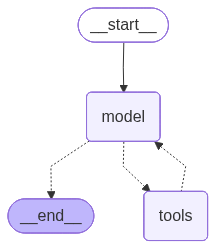

In [105]:
# 간단한 도구 정의
@tool
def get_current_time() -> str:
    """Get the current time."""
    from datetime import datetime

    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")


@tool
def greet(name: str) -> str:
    """Greet a person by name."""
    return f"Hello, {name}! Nice to meet you."


# 기본 Agent 생성
provider = "openai"
model_name = "gpt-4.1-mini"  # 사용할 모델 이름
basic_agent: CompiledStateGraph = create_agent(
    model=f"{provider}:{model_name}",
    tools=[get_current_time, greet],
    system_prompt="You are a friendly assistant. Use your tools to help users.",
    name="basic_agent",
)
basic_agent

In [106]:
# Basic Test
result = basic_agent.invoke(
    {
        "messages": [
            HumanMessage(
                content="What time is it now? Also, greet me. My name is Alice."
            )
        ]
    }
)

for msg in result["messages"]:
    if isinstance(msg, AIMessage) and not msg.tool_calls:
        msg.pretty_print()

HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


================================== Ai Message ==================================

The current time is 2025-10-22 16:18:05. Also, hello Alice! Nice to meet you. How can I assist you further?


---

# LangChain Middleware

**자세한 내용은 다음을 참조하세요:**
- [공식 문서](https://docs.langchain.com/oss/python/langchain/middleware)
- [LangChain Blog: Agent Middleware](https://blog.langchain.com/agent-middleware/)

## 2.1 Middleware 5가지 사전 정의 Decorator 요약
> 매 조건에 맞는 실행마다 데코레이터에 의해 Middleware 동작, 구현해야되는 파라미터 주의


| Type | Decorator | 실행 시점 | 주요 용도 | 반환 타입 |
|------|-----------|----------|-----------|-----------|
| Before Model | `@before_model` | LLM 호출 전 | 메시지 전처리, 컨텍스트 주입, 로깅 | `dict[str, Any]` or `None` |
| After Model | `@after_model` | LLM 응답 후 | 응답 검증, Guardrails, 후처리 | `dict[str, Any]` or `None` |
| Wrap Model Call | `@wrap_model_call` | LLM 호출 래핑 | Retry, Fallback, 에러 처리 | `AIMessage` |
| Dynamic Prompt | `@dynamic_prompt` | 프롬프트 생성 시 | 동적 시스템 프롬프트 생성 | `str` |
| Wrap Tool Call | `@wrap_tool_call` | Tool 실행 래핑 | Tool 에러 처리, Retry | `Any` |


## 2.2 설명하지 않은 Middleware Decorator 2가지
> @before_agent와 @after_agent는 Agent 실행 전/후 딱 1번씩만 실행됩니다.
1. @before_agent
2. @after_agent

---

**핵심 개념:**

1. **실행 순서:** Middleware 리스트의 첫 번째가 가장 바깥쪽 레이어
2. **State 업데이트:** 반환한 dict는 State에 merge됨 (덮어쓰기 아님)
3. **조합 가능:** 여러 middleware를 조합하여 복잡한 로직 구현

```python
agent = create_agent(
    model="...",
    tools=[...],
    middleware=[
        first_middleware,   # 가장 바깥쪽
        second_middleware,  # 중간
        third_middleware    # 가장 안쪽
    ]
)
```

## 2.3 5가지 Middleware Decorator 모두 사용하기

하나의 Agent에서 5가지 Middleware Decorator 를 모두 사용하는 예제입니다.


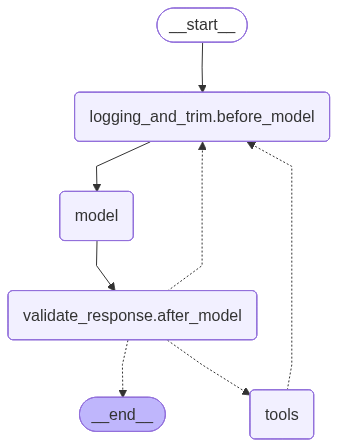

In [107]:
# 도구 정의
@tool
def calculate(expression: str) -> float:
    """Calculate a mathematical expression."""
    return eval(expression)


# 1. Before Model - Logging and message trimming
# Message Trimming 은 SummarizationMiddleware 로 대체 가능
@before_model
def logging_and_trim(state, runtime):
    """Log and trim messages before model call."""
    messages = state["messages"]
    print(f"[Before Model] Message count: {len(messages)}")

    # Trim if too many messages
    if len(messages) > 20:
        print(f"[Before Model] Trimming messages: {len(messages)} -> 20")
        return {"messages": messages[-20:]}
    return None


# 2. After Model - Response validation
# 모델 호출 이후 동작하므로, Guardrail 형태(from langchain.agents.middleware import PIIMiddleware, HumanInTheLoopMiddleware) 도 사용 가능
@after_model
def validate_response(state, runtime):
    """Validate model response."""
    last_msg = state["messages"][-1]
    if isinstance(last_msg, AIMessage):
        print(f"[After Model] Response validated: {len(last_msg.content)} chars")
    return None


# 3. Wrap Model Call - Retry on failure
# 모든 모델 호출에 대해 최대 3회 재시도하도록 로직 구성
@wrap_model_call
def retry_on_error(request, handler):
    """Retry model call up to 3 times on failure.

    Args:
        request: ModelRequest object containing the model invocation parameters
        handler: Callable that executes the actual model call

    Returns:
        ModelResponse from the successful model call
    """
    max_retries = 3
    for attempt in range(max_retries):
        try:
            print(f"[Wrap Model] Attempt {attempt + 1}/{max_retries}")
            response = handler(request)
            print(f"[Wrap Model] Success on attempt {attempt + 1}")
            return response
        except Exception as e:
            print(f"[Wrap Model] Error on attempt {attempt + 1}: {e}")
            if attempt == max_retries - 1:
                # 마지막 시도에서도 실패하면 예외 발생
                raise
            # 재시도 전 잠시 대기
            import time

            time.sleep(1)


# 4. Dynamic Prompt - Context-aware system prompt
@dynamic_prompt
def context_aware_prompt(request):
    """Generate context-aware system prompt.

    Args:
        request: Contains state with messages

    Returns:
        System prompt string based on context
    """
    messages = request.state["messages"]
    last_msg = messages[-1] if messages else None

    if last_msg and isinstance(last_msg, HumanMessage):
        if "calculate" in last_msg.content.lower():
            print("[Dynamic Prompt] Math context detected")
            return "You are a mathematics expert. Use the `calculate` tool for all math operations."
        else:
            print("[Dynamic Prompt] General context")
            return "You are a helpful assistant."

    return "You are a helpful assistant."


# 5. Wrap Tool Call - Tool error handling
@wrap_tool_call
def safe_tool_execution(request, handler):
    """Safely execute tools with error handling.

    Args:
        request: ToolCallRequest containing tool_call info (name, args, id)
        handler: Callable[[ToolCallRequest], ToolMessage | Command] that executes the tool

    Returns:
        ToolMessage from successful execution or error ToolMessage
    """
    try:
        tool_name = request.tool_call["name"]
        tool_args = request.tool_call["args"]
        print(f"[Wrap Tool] Executing {tool_name}")
        print(f"[Wrap Tool] Arguments: {tool_args}")

        result = handler(request)
        print(f"[Wrap Tool] Success: {tool_name}")
        return result
    except Exception as e:
        print(f"[Wrap Tool] Error in {tool_name}: {e}")
        # Return ToolMessage with error status
        from langchain_core.messages import ToolMessage

        return ToolMessage(
            content=f"Error executing {tool_name}: {str(e)}",
            tool_call_id=request.tool_call["id"],
            status="error",
        )


# Agent with all 5 middleware types
middleware_demo_agent = create_agent(
    model="openai:gpt-4o-mini",
    tools=[calculate],
    middleware=[
        logging_and_trim,  # 1. Before Model - 메시지 전처리
        validate_response,  # 2. After Model - 응답 검증
        retry_on_error,  # 3. Wrap Model Call - Retry 로직
        context_aware_prompt,  # 4. Dynamic Prompt - 동적 프롬프트
        safe_tool_execution,  # 5. Wrap Tool Call - Tool 에러 처리
    ],
    name="all_middleware_demo",
)
middleware_demo_agent

In [108]:
# Middleware Demo Test
result = middleware_demo_agent.invoke(
    {"messages": [HumanMessage(content="Calculate 25 * 4")]}
)

for msg in result["messages"]:
    if isinstance(msg, AIMessage) and not msg.tool_calls:
        msg.pretty_print()

[Before Model] Message count: 1
[Wrap Model] Attempt 1/3
[Dynamic Prompt] Math context detected


HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


[Wrap Model] Success on attempt 1
[After Model] Response validated: 0 chars
[Wrap Tool] Executing calculate
[Wrap Tool] Arguments: {'expression': '25 * 4'}
[Wrap Tool] Success: calculate
[Before Model] Message count: 3
[Wrap Model] Attempt 1/3


HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


[Wrap Model] Success on attempt 1
[After Model] Response validated: 39 chars
================================== Ai Message ==================================

The result of \( 25 \times 4 \) is 100.


# `create_agent()`의 한계점과 극복 방법

## 3.1 Prebuilt Agent의 한계점

`create_agent()`는 강력하지만 완벽하지는 않습니다.  
주요 한계점을 이해하고 극복 방법을 학습합니다.

### 주요 한계점

1. **고정된 Agent 로직**
   - 기본적으로 Prompt 를 수정하지 않으면, 기본적으로는 Tool 을 활용하는 `ReAct pattern`만을 기준으로 지원하는 상태.
     > 그래서 그래프 구조 수정 불가 
   > 그러나, Middleware로 커스터마이징 할 수 있고, `@dynamic_prompt` middleware 및 System Prompt 재정의도 가능함.

2. **제한적인 Tool 에러 처리**
   - 기본 에러 처리가 단순함
   - 복잡한 retry, tool limit 로직 구현 어려움
   > 그러나, tool description, args 고도화 및 Middleware로 보완 가능함.


### 제한사항 극복 전략

**방법 1: tool description, tool args - Pydantic BaseModel 로 고도화, Middleware 활용**
- Tool 실행 에러를 세밀하게 제어
- Pydantic BaseModel 을 활용하여 입력값 검증 및 변환 & Tool Args 를 Pydantic BaseModel 로 정의함으로써 Tool 의 신뢰성 향상
- 사용자 / 모델 친화적인 에러 메시지 전달

**방법 2: Prompt 재정의**
- 도메인 특화 System Prompt
- 역할별 맞춤 Prompt

**방법 3: Middleware 활용**
- 횡단 관심사 구현 (인증, 로깅, 모니터링)
- 커스텀 비즈니스 로직 추가
- Messages 기반의 Context Engineering 가능!

## 방법 1: tool description, tool args - Pydantic BaseModel 로 고도화, Middleware 활용한 에러 처리 강화

### 문제 상황

기본 `create_agent()`는 Tool 에러를 단순하게만 처리합니다.

```python
# 기본 동작
result = some_tool()  # 에러 발생 -> Agent 중단 또는 일반적인 에러 메시지
```

### 해결책: Middleware Decorator @wrap_tool_call 활용

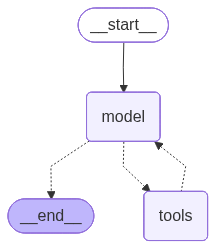

In [109]:
from langchain.agents.middleware import wrap_tool_call, ToolCallLimitMiddleware
from pydantic import BaseModel, Field, field_validator

class SqrtRequest(BaseModel):
    x: float = Field(..., description="Number to calculate square root of")

@tool(args_schema=SqrtRequest)
def sqrt(x: float) -> float:
    """Calculate square root of a number."""
    if x < 0:
        raise ValueError(f"Cannot calculate square root of negative number: {x}")
    return x**0.5

class SafeDivideRequest(BaseModel):
    """
    Safe division input schema.

    설명:
    - 두 숫자 a(분자)와 b(분모)를 받아 안전하게 나눗셈을 수행하기 위한 입력 스키마입니다.
    - LLM/도구 호출 시 이 스키마로 파싱되어 타입·값 검증이 자동으로 이루어집니다.

    사용 예:
    {
        "a": 10.0,        # Numerator (예: 10.0)
        "b": 2.5          # Denominator (예: 2.5, 절대 0 아님)
    }

    주의사항:
    - Pydantic은 가능한 경우 타입을 자동 변환합니다 (예: "2" -> 2.0).
    - 분모(b)는 0, NaN, Infinity가 될 수 없습니다.
    - ValidationError 발생 시 에이전트는 middleware에서 사용자 친화적 메시지로 처리하세요.
    """
    a: float = Field(
        ...,
        description="Numerator. 실수로 제공하세요. 예: 10.5",
        json_schema_extra={"examples": [10.5]},
    )
    b: float = Field(
        ...,
        description="Denominator. 0이 될 수 없습니다. 예: 2.0",
        json_schema_extra={"examples": [2.0]},
    )

    @field_validator("b")
    def b_must_not_be_zero_and_finite(cls, v):
        import math

        if v == 0:
            raise ValueError("Denominator must not be zero (b != 0).")
        if not math.isfinite(v):
            raise ValueError("Denominator must be a finite number (not NaN or Infinity).")
        return v

@tool(args_schema=SafeDivideRequest)
def safe_divide(a: float, b: float) -> float:
    """
    Safely divide two numbers.

    Returns:
        float: a / b

    Raises:
        ValueError: If b == 0 or b is not finite (NaN/Infinity).
    """
    import math

    if not math.isfinite(a):
        raise ValueError("Numerator must be a finite number.")
    if not math.isfinite(b) or b == 0:
        raise ValueError("Denominator must be a finite non-zero number.")
    return a / b

# Limit all tool calls - Tool Call Limit 을 지정해서, 너무 많이 실행하지 않도록 제어
global_limiter = ToolCallLimitMiddleware(thread_limit=20, run_limit=10)

# wrap_tool_call middleware로 에러 핸들링 구현
@wrap_tool_call
def tool_error_handler(request, handler):
    """Tool error handler with detailed, user-friendly messages.

    Args:
        request: Tool call request
        handler: Tool execution handler

    Returns:
        ToolMessage with result or error message
    """
    try:
        # Execute the tool
        return handler(request)
    except Exception as error:
        # Extract tool call info
        tool_call = request.tool_call
        tool_name = tool_call.get("name", "Unknown")
        args = tool_call.get("args", {})

        # Generate user-friendly error message
        if isinstance(error, ValueError):
            if "negative" in str(error).lower():
                error_msg = f"""Error in {tool_name}: Cannot calculate square root of negative numbers.

Hint: Square roots are only defined for non-negative real numbers.
Input: {args}
Suggestion: Check if you meant to use absolute value first."""
            elif "zero" in str(error).lower():
                error_msg = f"""Error in {tool_name}: Division by zero is undefined.

Input: numerator={args.get("a")}, denominator={args.get("b")}
Suggestion: Verify the denominator value."""
            else:
                error_msg = f"Error in {tool_name}: {str(error)}. Input: {args}"
        else:
            error_msg = f"Error in {tool_name}: {str(error)}. Input: {args}"

        # Return error as ToolMessage
        return ToolMessage(content=error_msg, tool_call_id=tool_call["id"])


# create_agent with middleware (LangChain 1.0 방식)
agent_custom_error = create_agent(
    model="openai:gpt-4.1-mini",
    tools=[sqrt, safe_divide],
    middleware=[tool_error_handler],  # Tool 에러 핸들링은 middleware로
    system_prompt="""You are a mathematics assistant with advanced error handling.
When encountering errors:
1. Explain the error clearly
2. Suggest alternatives
3. Never retry the same failing operation""",
)

agent_custom_error

In [111]:
# 테스트: 기본 에러 처리 - 음수의 제곱근
result = agent_custom_error.invoke(
    {"messages": [HumanMessage(content="Calculate square root of -16. Respond in Korean.")]}
)

for msg in result["messages"]:
    if isinstance(msg, ToolMessage):
        print(f"Tool 에러: {msg.content}")
    elif isinstance(msg, AIMessage) and not msg.tool_calls:
        print(f"\nAgent 응답: {msg.content}")

HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"



Agent 응답: 음수 -16의 제곱근은 실수 범위에서 정의되지 않습니다. 복소수 범위에서는 제곱근이 존재하지만, 여기서는 복소수 계산이 제공되지 않습니다. 

대안으로는 절댓값 16의 제곱근을 구하고, 결과에 허수 단위 i를 곱하여 표현할 수 있습니다. 즉, √(-16) = 4i 가 됩니다.


### Middleware 요약

**LangChain 1.0: Middleware로 에러 핸들링**
1. Tool 에러를 사용자 친화적 메시지로 변환
2. Agent가 에러 상황을 이해하고 대응 가능
3. 컨텍스트와 해결 방법 제시
4. Agent 중단 방지

**핵심 패턴 (LangChain 1.0):**
```python
from langchain.agents.middleware import wrap_tool_call

@wrap_tool_call
def custom_error_handler(request, handler):
    try:
        return handler(request)
    except Exception as e:
        return ToolMessage(
            content=f"Error: {str(e)}",
            tool_call_id=request.tool_call["id"]
        )

agent = create_agent(
    model="...",
    tools=[...],  # 일반 tool 리스트
    middleware=[custom_error_handler],  # 에러 핸들링은 middleware로
)
```

**V1.0 중요 변경사항:**
- `create_agent`는 더 이상 `ToolNode`를 `tools` 파라미터로 받지 않음
- **`tools` 파라미터에는 일반 tool 리스트만 전달 가능**
- **에러 핸들링은 `@wrap_tool_call` middleware 사용**
- **ToolCallLimitMiddleware 등으로 툴콜링 리밋을 활용할 수 있음**


# 방법 2 - Prompt 재정의를 통한 Agentic & 도메인 특화 가능

## 4.1 문제 상황

기본 `create_agent()`는 범용 Agent입니다.  
원하는 도메인 내에서 딱 정확한 Agentic 한 동작이 부적절할 수도 있습니다.

### 해결책: 도메인 특화 System Prompt

정교하게 작성된 System Prompt(또는 @dynamic_prompt)로 Agent를 지정된 작업에 최적화합니다.

## 4.2 예제: 금융 자문 Agent

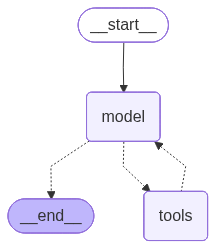

In [113]:
# 금융 관련 도구라고 가정

class CompoundInterest(BaseModel):
    """"""
    principal: float = Field(..., description="Initial investment amount")
    rate: float = Field(..., description="Annual interest rate (e.g., 5 for 5%)")
    years: int = Field(..., description="Investment period in years")

@tool(args_schema=CompoundInterest)
def calculate_compound_interest(principal: float, rate: float, years: int) -> dict:
    """Calculate compound interest."""

    rate_decimal = rate / 100
    final_amount = principal * ((1 + rate_decimal) ** years)
    interest = final_amount - principal

    return {
        "principal": f"{principal:,.0f}",
        "final_amount": f"{final_amount:,.0f}",
        "interest_earned": f"{interest:,.0f}",
        "return_rate": f"{(interest / principal) * 100:.2f}%",
    }


@tool
def assess_investment_risk(investment_type: str) -> str:
    """Assess risk level of investment type.

    Args:
        investment_type: Type of investment (stocks, bonds, savings, real_estate)

    Returns:
        Risk assessment
    """
    risks = {
        "savings": "Very Low Risk - Principal protected, stable returns",
        "bonds": "Low Risk - Relatively stable, interest income",
        "real_estate": "Medium Risk - Market dependent, illiquid",
        "stocks": "High Risk - High potential returns, significant volatility",
        "crypto": "Very High Risk - Extreme volatility, speculative",
    }
    return risks.get(investment_type.lower(), "Risk information not available")


# 도메인 특화 Prompt - 금융 상담사 역할 정의
FINANCIAL_ADVISOR_PROMPT = """
You are a professional financial advisor with expertise in personal finance.

[Your Role]
- Help clients achieve their financial goals
- Explain complex financial concepts simply
- Always comply with ethical standards

[Behavior Guidelines]
1. Safety First: Always check risk levels before recommendations
2. Transparency: Clearly explain calculations and assumptions
3. Balanced Advice: Present both pros and cons
4. Disclaimer: Remind clients that investment decisions are their responsibility

[Response Format]
1. Acknowledge client's question
2. Gather necessary information (use tools)
3. Provide analysis with clear reasoning
4. Give specific recommendations
5. ALWAYS end with: "This information is for reference only. Please consult with a licensed financial advisor for personalized advice."
6. ALWAYS respond language in **Korean**

[Prohibited Actions]
- Never guarantee specific returns
- Never provide tax or legal advice
- Never pressure clients into decisions
"""

financial_advisor = create_agent(
    model="openai:gpt-4.1",
    tools=[calculate_compound_interest, assess_investment_risk],
    system_prompt=FINANCIAL_ADVISOR_PROMPT,
    name="financial_advisor",
)
financial_advisor

In [114]:
# 도메인 특화 Prompt - 금융 상담사 역할 정의 테스트
result = financial_advisor.invoke(
    {
        "messages": [
            HumanMessage(
                content="I want to invest $10,000 for 10 years at 5% annual interest. Should I choose stocks or bonds? Respond in Korean."
            )
        ]
    }
)

for msg in result["messages"]:
    if isinstance(msg, AIMessage) and not msg.tool_calls:
        msg.pretty_print()

HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"



Agent 응답:
================================== Ai Message ==================================

질문해 주셔서 감사합니다. $10,000을 5% 연이율로 10년간 투자할 경우, 예시 계산 결과와 각각 투자 수단(주식, 채권)의 위험도를 아래와 같이 분석해 드립니다.

1. 분석 결과
- 복리로 10년간 5%로 투자할 경우 최종 금액은 약 $16,289가 되며, 총 이자는 $6,289입니다.
- 주식 투자의 경우: 높은 위험, 높은 잠재 수익. 가격 변동성이 크므로 원금 손실 가능성도 있습니다.
- 채권 투자의 경우: 낮은 위험, 상대적으로 안정적이며 정기적 이자 수익이 가능합니다. 다만, 잠재 수익률은 주식보다 낮을 수 있습니다.

2. 구체적 제안
- 안정성과 예측 가능한 수익을 원한다면 채권이 적합합니다.
- 더 높은 수익을 기대하며 위험을 감수할 수 있다면 주식을 고려해볼 수 있습니다.
- 투자 포트폴리오를 분산시켜 양쪽에 일부씩 투자하는 방법(예: 50% 주식, 50% 채권)도 위험과 수익을 균형 있게 관리하는 데 도움이 됩니다.

항상 본인의 투자 성향(위험 감수도, 투자 목적, 필요 자금 시점 등)을 충분히 고려해야 하며, 상기 정보는 참고용입니다. 투자 결정 전 반드시 공인 금융 전문가와 개별 상담하시길 권장드립니다.

이 정보는 참고용입니다. 보다 맞춤화된 상담을 원하신다면 반드시 공인된 금융 전문가와 상담하시기 바랍니다.


# 방법 3 - Middleware 커스터마이징

## 5.1 횡단 관심사 (Cross-Cutting Concerns)

인증, 할당량 관리, 로깅, PII, Guardrail 같은 기능은 모든 Agent에 공통으로 필요합니다.
> 해결책: 재사용 가능한 Middleware 를 통해 공통 기능 정의

[Custom Middlewre 공식 문서](https://docs.langchain.com/oss/python/langchain/middleware#custom-middleware)

## 5.2 엔터프라이즈용 Middleware 기능을 갖춘 create_agent 기반의 LangGraph Agent

In [115]:
# 사용자 데이터베이스 시뮬레이션
from langchain.agents.middleware import (
    before_model, 
    after_model, 
    wrap_model_call, 
    dynamic_prompt,
    PIIMiddleware, 
    AgentState, 
    ModelRequest, 
    ModelResponse, 
)
from langchain.messages import AIMessage
from langchain.agents import create_agent
from langgraph.runtime import Runtime
from typing import Any, Callable

USER_DB = {
    "user_001": {"name": "Alice", "role": "admin", "quota": 100, "used": 0},
    "user_002": {"name": "Bob", "role": "user", "quota": 10, "used": 0},
}

METRICS_DB = {"total_calls": 0, "total_errors": 0, "call_history": []}


# 인증 Middleware - Auth 기능을 LangSmith 영역으로 따로 지원하고 있기는 합니다.
# NOTE: https://docs.langchain.com/langsmith/auth
@before_model # TODO: Before Agent 가 더 났지 않을까요?
def authentication_middleware(state, runtime):
    """Authenticate user and check quota.

    Args:
        state: Current state
        runtime: Runtime context

    Returns:
        None if authenticated, raises exception otherwise
    """
    # Runtime context에서 user_id 추출
    user_id = (
        getattr(runtime.context, "user_id", None)
        if hasattr(runtime, "context")
        else None
    )

    if not user_id or user_id not in USER_DB:
        print(f"[Auth] Failed: Invalid user '{user_id}'")
        # 실제로는 Exception 발생, 여기서는 로그만
        return None

    user = USER_DB[user_id]
    if user["used"] >= user["quota"]:
        print(f"[Auth] Quota exceeded for {user['name']}")
        return None

    user["used"] += 1
    print(
        f"[Auth] Authenticated: {user['name']} ({user['role']}) - Remaining: {user['quota'] - user['used']}"
    )
    return None


# 메트릭 수집 Middleware
@wrap_model_call
def metrics_collection_middleware(request, handler):
    """Collect metrics on model calls.

    Args:
        request: Model request
        handler: Actual handler function

    Returns:
        Model response
    """
    start_time = time.time()

    try:
        response = handler(request)
        latency = time.time() - start_time

        # 메트릭 저장
        METRICS_DB["total_calls"] += 1
        METRICS_DB["call_history"].append(
            {
                "timestamp": datetime.now().isoformat(),
                "latency": latency,
                "success": True,
            }
        )

        print(f"[Metrics] Call #{METRICS_DB['total_calls']} - Latency: {latency:.2f}s")
        return response

    except Exception as e:
        latency = time.time() - start_time
        METRICS_DB["total_errors"] += 1
        METRICS_DB["call_history"].append(
            {
                "timestamp": datetime.now().isoformat(),
                "latency": latency,
                "success": False,
                "error": str(e),
            }
        )
        print(f"[Metrics] Error - Latency: {latency:.2f}s")
        raise

@wrap_model_call
def retry_model(
    request: ModelRequest,
    handler: Callable[[ModelRequest], ModelResponse],
) -> ModelResponse:
    for attempt in range(3):
        try:
            return handler(request)
        except Exception as e:
            if attempt == 2:
                raise
            print(f"Retry {attempt + 1}/3 after error: {e}")

In [117]:
# 여러 편의 기능을 갖춘 Enterprise Agent 예제
# 프로덕션에서는 커스텀 middleware로 구현하거나 외부 라이브러리 사용
enterprise_agent = create_agent(
    model="openai:gpt-4.1-mini",
    tools=[],
    system_prompt="You are a secure enterprise mathematics assistant.",
    middleware=[
        authentication_middleware,  # 인증
        metrics_collection_middleware,  # 메트릭
        retry_model,  # 재시도
        ############ PII Middleware 설정 ############
        # 사용자 입력에서 이메일 주소 삭제
        PIIMiddleware("email", strategy="redact"),
        # 신용 카드 번호 마스킹 (마지막 4자리 표시)
        PIIMiddleware("credit_card", strategy="mask"),
        # API 키 블록 처리
        PIIMiddleware(
            "api_key",
            strategy="block",  # Raise error if detected
            detector=r"sk-[a-zA-Z0-9]{32}",
            apply_to_input=True,  # Explicit, consistent with others
        ),
    ],
)

## Section 6.1: Enterprise Agent 테스트

PII Middleware가 제대로 작동하는지 다양한 시나리오로 테스트합니다.

### 테스트 시나리오:
1. **이메일 Redaction**: 이메일 주소가 `[REDACTED_email]`로 변환되는지 확인
2. **신용카드 Masking**: 신용카드 번호가 부분 마스킹되는지 확인 (마지막 4자리만 표시)
3. **API 키 Blocking**: API 키 패턴이 감지되면 에러가 발생하는지 확인

In [118]:
# Email Redaction (이메일 삭제) 테스트
email_query = "My email is Hyunjun.jeon@gmail.com and I need help with math."

print(f"\n[Input] {email_query}")
print("\n[Expected] 이메일 주소가 [REDACTED_email]로 변환됨")
print("\n[Processing...]\n")

result = enterprise_agent.invoke(
    {"messages": [{"role": "user", "content": email_query}]}
)

# Check if email was redacted in the state
last_human_msg = None
for msg in result["messages"]:
    if msg.type == "human":
        last_human_msg = msg

print(f"[Result] Processed message: {last_human_msg}")

if "[REDACTED_email]" in last_human_msg.content:
    print("✓ Test 1 PASSED: Email successfully redacted")
elif "john.doe@example.com" not in last_human_msg.content:
    print("✓ Test 1 PASSED: Email was removed (redaction method may vary)")
else:
    print("✗ Test 1 FAILED: Email not redacted")

print(f"\n[AI Response] {result['messages'][-1].content}")


[Input] My email is Hyunjun.jeon@gmail.com and I need help with math.

[Expected] 이메일 주소가 [REDACTED_email]로 변환됨

[Processing...]

[Auth] Failed: Invalid user 'None'


HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


[Metrics] Call #1 - Latency: 1.24s
[Result] Processed message: content='My email is [REDACTED_EMAIL] and I need help with math.' additional_kwargs={} response_metadata={} id='85f95f83-6480-4d9f-a614-9702ff8e3796'
✓ Test 1 PASSED: Email was removed (redaction method may vary)

[AI Response] Hello! I'd be happy to help you with math. Could you please tell me what specific math problem or topic you need assistance with?


### Credit Card 검출과 Luhn 알고리즘

LangChain의 `PIIMiddleware`는 신용카드 번호를 검출할 때 **Luhn 알고리즘**(체크섬 검증)을 사용합니다.

**Luhn 알고리즘이란?**
- 신용카드, 직불카드 등의 번호 유효성을 검증하는 체크섬 알고리즘
- 1954년 IBM의 Hans Peter Luhn이 개발
- 단순 오타는 잡아내지만, 보안 검증은 아님

**왜 중요한가?**
- `4532-1234-5678-9010` 같은 무작위 번호는 Luhn 검증 실패 → 검출 안됨
- 실제 카드 번호나 Luhn-valid 테스트 카드만 검출됨
- **False Negative 방지**: 진짜 카드 번호만 마스킹하여 불필요한 검출 방지

**업계 표준 테스트 카드 번호:**
```
Visa:       4532015112830366
Mastercard: 5425233430109903
Discover:   6011111111111117
```

이 테스트에서는 **Visa 테스트 카드(4532015112830366)**를 사용합니다.

In [119]:
# Credit Card Masking (신용카드 마스킹) 테스트

# Luhn-valid test credit card number (Visa test card)
cc_query = "I used card 4532015112830366 for payment. Can you help?"

print(f"\n[Input] {cc_query}")
print("\n[Expected] 신용카드 번호가 ************0366 형태로 마스킹됨 (마지막 4자리만 표시)")
print("\n[Processing...]\n")

result = enterprise_agent.invoke(
    {"messages": [{"role": "human", "content": cc_query}]}
)

# Check if credit card was masked
last_human_msg: HumanMessage = HumanMessage(content="")
for msg in result["messages"]:
    if msg.type == "human":
        last_human_msg = msg

print(f"[Result] Processed message: {last_human_msg.content}")

# Check for masking
if "4532015112830366" not in last_human_msg.content:
    if "0366" in last_human_msg.content:  # Last 4 digits preserved
        print("✓ Test 2 PASSED: Credit card masked with last 4 digits visible")
        # Show the masking pattern
        if "*" in last_human_msg.content:
            print("   Masking pattern used: asterisks (*)")
    else:
        print("✓ Test 2 PASSED: Credit card was fully redacted")
else:
    print("Test 2 FAILED: Credit card not masked")
    print("   Original number still present: 4532015112830366")

print(f"\n[AI Response] {result['messages'][-1].content}")


[Input] I used card 4532015112830366 for payment. Can you help?

[Expected] 신용카드 번호가 ************0366 형태로 마스킹됨 (마지막 4자리만 표시)

[Processing...]

[Auth] Failed: Invalid user 'None'


HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


[Metrics] Call #2 - Latency: 0.85s
[Result] Processed message: I used card ************0366 for payment. Can you help?
✓ Test 2 PASSED: Credit card masked with last 4 digits visible
   Masking pattern used: asterisks (*)

[AI Response] I'm here to help! However, for your security, please avoid sharing sensitive information such as full card numbers. How can I assist you with your payment?


In [120]:
# API Key Blocking (API 키 차단) 테스트

# Generate a fake API key matching the pattern sk-[a-zA-Z0-9]{32}
api_key_query = "My API key is sk-abcd1234efgh5678ijkl9012mnop3456 and I need help."

print(f"\n[Input] {api_key_query}")
print("\n[Expected] PIIDetectionError 발생하여 실행 차단")
print("\n[Processing...]\n")

try:
    result = enterprise_agent.invoke(
        {"messages": [{"role": "user", "content": api_key_query}]}
    )
    print("✗ Test 3 FAILED: API key was not blocked (no exception raised)")
    print(f"Result: {result['messages'][-1].content}")
    
except Exception as e:
    if "api_key" in str(e).lower() or "pii" in str(e).lower():
        print("Test 3 PASSED: API key blocked with error")
        print(f"[Error Type] {type(e).__name__}")
        print(f"[Error Message] {str(e)[:200]}")
    else:
        print("Test 3 FAILED: Unexpected error")
        print(f"[Error] {type(e).__name__}: {e}")


[Input] My API key is sk-abcd1234efgh5678ijkl9012mnop3456 and I need help.

[Expected] PIIDetectionError 발생하여 실행 차단

[Processing...]

[Auth] Failed: Invalid user 'None'
Test 3 PASSED: API key blocked with error
[Error Type] PIIDetectionError
[Error Message] Detected 1 instance(s) of api_key in text content


---

# Supervisor 패턴 - Multi-Agent System 구축

## 6.1 Supervisor 패턴이란?

**Supervisor 패턴**은 하나의 중앙 Agent(Supervisor)가 여러 전문화된 Worker Agent들을 조율하는 계층적 Multi-Agent 아키텍처입니다.

### 아키텍처

```
User Query
    |
    v
[Supervisor Agent]
    |---> [Worker Agent 1] (Math Expert)
    |---> [Worker Agent 2] (Research Expert)
    |---> [Worker Agent 3] (Writing Expert)
    |
    v
Final Response
```

### 핵심 개념

1. **Supervisor Agent**: 작업을 분석하고 적절한 Worker에게 위임
2. **Worker Agents**: 특정 도메인의 전문가 (도구와 Prompt로 특화)
3. **Delegation Mechanism**: Tool-based handoff로 제어권 전달
4. **Message History Management**: Worker 응답을 Supervisor 히스토리에 통합

### Delegation(할당) 메커니즘

Supervisor가 Worker를 호출하는 방법은 **Tool-based handsoff** 가 대표적입니다:

1. Supervisor는 각 Worker에 대한 "handoff tool"을 보유
2. Supervisor가 Worker의 handoff tool을 호출
3. LangGraph가 해당 Worker Agent로 제어권 전달
4. Worker가 작업 수행 후 결과 반환
5. Supervisor가 결과 수신 및 최종 응답 생성

# `create_supervisor()` 기반 Multi-Agent 시스템

`langgraph-supervisor` 라이브러리는 Supervisor 패턴을 간편하게 구현할 수 있는 prebuilt 함수를 제공합니다.  
**참고:** [langgraph-supervisor GitHub](https://github.com/langchain-ai/langgraph-supervisor-py)

### 주요 기능

1. **자동 Handoff Tool 생성**: Worker Agent마다 자동으로 handoff tool 생성
2. **Message History 관리**: `output_mode` 파라미터로 간편 제어
3. **Multi-level Hierarchy 지원**: Supervisor가 다른 Supervisor를 관리 가능
4. **메모리 시스템 통합**: Checkpointer와 Store 지원

### 기본 사용법

```python
from langgraph_supervisor import create_supervisor
from langchain.agents import create_agent

# Worker Agent 생성 (name 필수!)
worker1 = create_agent(model=model, tools=[...], name="worker1")
worker2 = create_agent(model=model, tools=[...], name="worker2")

# Supervisor 생성
workflow = create_supervisor(
    agents=[worker1, worker2],
    model=model,
    prompt="You are a supervisor managing...",
)

# 컴파일 및 실행
app = workflow.compile()
result = app.invoke({"messages": [...]})
```

## 예제: 고객 지원 Multi-Agent 시스템

3개의 전문화된 Worker Agent를 관리하는 고객 지원 시스템을 구축합니다:

- **technical_support**: 기술 문제 해결
- **billing_support**: 결제 및 청구 문제
- **general_support**: 일반 문의

In [124]:
# Technical Support Tools
@tool
def check_system_status(service_name: Literal["api", "database", "auth", "storage"]) -> str:
    """서비스의 운영 상태를 확인합니다."""
    
    statuses = {
        "api": "운영 중 - 응답 시간: 120ms",
        "database": "성능 저하 - 높은 부하 감지",
        "auth": "운영 중 - 모든 인증 서비스 정상 작동",
        "storage": "운영 중 - 사용량 78%",
    }
    return statuses.get(service_name.lower(), "서비스를 찾을 수 없습니다")


@tool
def restart_service(service_name: str) -> str:
    """서비스를 재시작합니다 (관리자 전용).

    Args:
        service_name: 재시작할 서비스 이름

    Returns:
        재시작 상태 문자열
    """
    return f"서비스 '{service_name}'가 성공적으로 재시작되었습니다. 예상 다운타임: 30초."


# Billing Support Tools
@tool
def get_invoice(customer_id: str) -> str:
    """고객의 청구서 정보를 조회합니다.

    Args:
        customer_id: 고객 ID

    Returns:
        청구서 상세 정보 문자열
    """
    return f"""고객 {customer_id}님의 청구서:
- 최근 청구액: $249.99 (결제일: 2024-01-15)
- 현재 잔액: $0.00
- 다음 결제일: 2024-02-15
- 요금제: Professional Monthly"""


@tool
def process_refund(customer_id: str, amount: float, reason: str) -> str:
    """환불 요청을 처리합니다.

    Args:
        customer_id: 고객 ID
        amount: 환불 금액(달러)
        reason: 환불 사유

    Returns:
        환불 처리 확인 문자열
    """
    return f"환불 처리 완료: ${amount} - 고객 {customer_id}. 사유: {reason}. 처리 완료까지 5-7 영업일 소요될 예정입니다."


# General Support Tools
@tool
def search_knowledge_base(query: str) -> str:
    """지식베이스에서 관련 답변을 검색합니다.

    Args:
        query: 검색 쿼리

    Returns:
        검색 결과 문자열
    """
    kb = {
        "password": "비밀번호를 재설정하려면 설정 > 보안 > 비밀번호 재설정으로 이동하세요.",
        "api": "API 문서는 https://docs.example.com/api 에서 확인할 수 있습니다.",
        "billing": "청구 관련 정보는 계정 > 청구 섹션에서 확인하세요.",
    }

    for key, value in kb.items():
        if key in query.lower():
            return f"찾음: {value}"

    return "정확한 일치 항목을 찾지 못했습니다. 지원팀에 문의해 주세요."

In [125]:
# Model 초기화
support_model = ChatOpenAI(model="gpt-4.1-mini", temperature=0)

# Worker Agent 1: Technical Support
technical_support = create_agent(
    model=support_model,
    tools=[check_system_status, restart_service],
    name="technical_support",
    system_prompt="""You are a technical support specialist.

Responsibilities:
- Diagnose technical issues
- Check system status
- Restart services when necessary
- Provide clear technical explanations

Always check system status before suggesting restarts.""",
)

# Worker Agent 2: Billing Support
billing_support = create_agent(
    model=support_model,
    tools=[get_invoice, process_refund],
    name="billing_support",
    system_prompt="""You are a billing support specialist.

Responsibilities:
- Handle billing inquiries
- Retrieve invoice information
- Process refunds (be cautious)

Always verify customer information before processing refunds.""",
)

# Worker Agent 3: General Support
general_support = create_agent(
    model=support_model,
    tools=[search_knowledge_base],
    name="general_support",
    system_prompt="""You are a general customer support specialist.

Responsibilities:
- Answer general questions
- Search knowledge base
- Provide friendly assistance

Be helpful and professional.""",
)

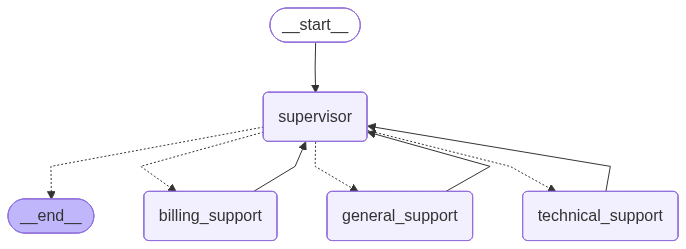

In [126]:
supervisor_model = ChatOpenAI(model="gpt-4.1", temperature=0)
customer_support_supervisor: StateGraph = create_supervisor(
    model=supervisor_model,
    agents=[technical_support, billing_support, general_support],
    prompt="""You are a customer support supervisor managing a team of specialists.

Your team:
- technical_support: System issues, performance, errors
- billing_support: Invoices, payments, refunds
- general_support: General questions, documentation

Decision process:
1. Analyze the customer request
2. Determine which specialist is best suited
3. Delegate to the appropriate specialist
4. Review the specialist's response
5. Provide final response to customer

Rules:
- Delegate to exactly ONE specialist per issue
- If unclear, ask clarifying questions first
- Always be professional and empathetic""",
    output_mode="last_message",  # 토큰 절약
    parallel_tool_calls=False,  # 한 번에 한 명의 specialist만
)

customer_support_app = customer_support_supervisor.compile()
customer_support_app

In [127]:
# Technical Issue (Should route to technical_support) 테스트
result1 = customer_support_app.invoke(
    {
        "messages": [
            HumanMessage(
                content="My application is running very slow. Can you check if there are any issues? Answer in Korean."
            )
        ]
    }
)

for msg in result1["messages"]:
    if isinstance(msg, AIMessage) and not msg.tool_calls:
        msg.pretty_print()
        break

HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


================================== Ai Message ==================================

현재 시스템 상태를 확인한 결과, API 서비스는 120ms의 응답 시간으로 운영 중이며, 데이터베이스는 성능 저하가 발생하여 느린 부하가 감지되었습니다. 인증 서비스는 정상 작동 중이고, 스토리지 사용량은 78%로 정상 범위 내에 있습니다. 데이터베이스 성능 저하가 애플리케이션 속도 저하의 주요 원인으로 보입니다. 데이터베이스 서비스를 재시작하여 문제를 해결할 수 있는지 시도해 보시겠습니까?


In [128]:
# Billing Issue (Should route to billing_support) 테스트
result2 = customer_support_app.invoke(
    {
        "messages": [
            HumanMessage(
                content="I need to see my latest invoice for customer ID C12345. Answer in Korean."
            )
        ]
    }
)

for msg in result2["messages"]:
    if isinstance(msg, AIMessage) and not msg.tool_calls:
        msg.pretty_print()
        break

HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


================================== Ai Message ==================================

고객님, 고객 ID C12345의 최신 청구서는 다음과 같습니다:
- 최근 청구액: $249.99 (결제일: 2024-01-15)
- 현재 잔액: $0.00
- 다음 결제일: 2024-02-15
- 요금제: Professional Monthly

더 궁금한 점 있으시면 말씀해 주세요.


In [129]:
# General Question (Should route to general_support) 테스트
result3 = customer_support_app.invoke(
    {"messages": [HumanMessage(content="How do I reset my password? Answer in Korean.")]}
)

for msg in result3["messages"]:
    if isinstance(msg, AIMessage) and not msg.tool_calls:
        msg.pretty_print()
        break

HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


================================== Ai Message ==================================

비밀번호 재설정 방법에 대한 정확한 정보를 찾지 못했습니다. 일반적으로 비밀번호를 재설정하려면 로그인 화면에서 '비밀번호를 잊으셨나요?' 또는 '비밀번호 재설정' 링크를 클릭한 후, 등록된 이메일 주소를 입력하여 재설정 링크를 받는 절차를 따릅니다. 만약 이 방법으로 해결되지 않으면 고객 지원팀에 문의해 주시기 바랍니다. 도움이 필요하시면 언제든지 말씀해 주세요!


---

## `create_supervisor()`의 한계점과 실전 해결 방법

### 문제 정의

`create_supervisor()`는 **tool-based delegation**을 사용합니다.  
Supervisor LLM이 handoff tool을 호출하여 Worker에게 작업을 위임하는 방식입니다.

**이 접근 방식의 근본적인 문제:**

#### **1. LLM이 Tool을 호출하지 않을 수 있음** 

LLM의 tool calling은 **확률적(probabilistic)** 행동입니다.  

> 아무리 좋은 prompt를 작성해도:  
- Supervisor가 직접 답변을 시도할 수도 있음
- 잘못된 Worker를 선택할 수 있음(Tool 호출 자체를 하지 않을 수 있음)

```python
# 사용자: "What's 15 * 23?"
# 
# 예상: Supervisor → transfer_to_math_expert() 호출
# 실제: Supervisor가 직접 "The answer is 345" 응답
#       (Tool을 호출하지 않음!)
```

**문제:**
- Worker가 정확한 답변을 생성해도
- Supervisor가 이를 재작성하면서 정보 왜곡
- "전화 게임(telephone game)" 효과

**성능 영향:**
- Translation layer가 **50%의 오류 원인**
- 토큰 사용량 증가

#### **3. 작은 모델(SLM)의 Tool Calling 불안정성**

Open source LLM 또는 20B 이하의 작은 모델에서:
- JSON 생성 오류(Structured Output 오류)
- Tool calling format 이해 실패, 엉뚱한 도구 호출 및 지속적 도구 호출
- Context overflow 시 더욱 불안정

---

### 해결 방법 개요

다음 섹션에서 3가지 실전 해결 방법을 학습합니다:

1. **Custom Tool Descriptions**: Tool 설명을 매우 구체적으로하여 Tool 호출 유도
2. **Post-Model Guardrail**: Delegation 실패를 감지 및 복구하는 로직
3. **Forced Delegation**: Conditional edges로 100% 보장하도록 코드로 강제 구현

In [130]:
from langgraph_supervisor import create_handoff_tool

print("=" * 70)
print("기본 Tool Description vs 개선된 Tool Description 비교")
print("=" * 70)

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# BAD: 기본 handoff tool (자동 생성)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print("\n기본 방식 (문제 있음):")
basic_handoff = create_handoff_tool(
    agent_name="technical_support",
    # description 지정 안 하면 기본값: "Ask agent 'technical_support' for help"
)
print(f"  Tool name: {basic_handoff.name}")
print(f"  Description: {basic_handoff.description}")
print("  → 너무 일반적! Supervisor가 언제 사용해야 할지 모름")

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# GOOD: 구체적인 handoff tool
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print("\n\n개선된 방식 (권장):")

tech_handoff = create_handoff_tool(
    agent_name="technical_support",
    name="delegate_to_tech_support",
    description="""
Delegate to TECHNICAL SUPPORT specialist for:

WHEN TO USE:
✓ System errors, bugs, or crashes
✓ API failures, integration issues
✓ Performance problems (slow, timeout)
✓ Service status checks
✓ Technical troubleshooting

DO NOT USE FOR:
✗ Billing, invoices, or payment issues
✗ Account management questions
✗ General product information
✗ Password resets (use general_support)

EXAMPLES:
- "My API is returning 500 errors" → USE
- "The app keeps crashing" → USE
- "How do I pay my bill?" → DO NOT USE
- "What's your pricing?" → DO NOT USE
    """.strip(),
)

billing_handoff = create_handoff_tool(
    agent_name="billing_support",
    name="delegate_to_billing",
    description="""
Delegate to BILLING SUPPORT specialist for:

WHEN TO USE:
- Invoice questions or requests
- Payment issues or refunds
- Subscription changes
- Pricing information
- Billing disputes

DO NOT USE FOR:
- Technical issues or errors
- System troubleshooting
- General product questions

EXAMPLES:
- "I need my latest invoice" → USE
- "Can I get a refund?" → USE
- "My API isn't working" → DO NOT USE
- "How do I use feature X?" → DO NOT USE
    """.strip(),
)

general_handoff = create_handoff_tool(
    agent_name="general_support",
    name="delegate_to_general",
    description="""
Delegate to GENERAL SUPPORT specialist for:

WHEN TO USE:
- Product information, features
- How-to questions, documentation
- Account setup, password resets
- General inquiries
- Questions that don't fit tech or billing

DO NOT USE FOR:
- System errors or bugs → tech_support
- Billing or invoices → billing_support

EXAMPLES:
- "How do I reset my password?" → USE
- "What features do you have?" → USE
- "My payment failed" → DO NOT USE (billing)
- "API is down" → DO NOT USE (tech)
    """.strip(),
)

print(f"\nTech support description ({len(tech_handoff.description)} 문자):")
print(tech_handoff.description)

기본 Tool Description vs 개선된 Tool Description 비교

기본 방식 (문제 있음):
  Tool name: transfer_to_technical_support
  Description: Ask agent 'technical_support' for help
  → 너무 일반적! Supervisor가 언제 사용해야 할지 모름


개선된 방식 (권장):

Tech support description (538 문자):
Delegate to TECHNICAL SUPPORT specialist for:

WHEN TO USE:
✓ System errors, bugs, or crashes
✓ API failures, integration issues
✓ Performance problems (slow, timeout)
✓ Service status checks
✓ Technical troubleshooting

DO NOT USE FOR:
✗ Billing, invoices, or payment issues
✗ Account management questions
✗ General product information
✗ Password resets (use general_support)

EXAMPLES:
- "My API is returning 500 errors" → USE
- "The app keeps crashing" → USE
- "How do I pay my bill?" → DO NOT USE
- "What's your pricing?" → DO NOT USE


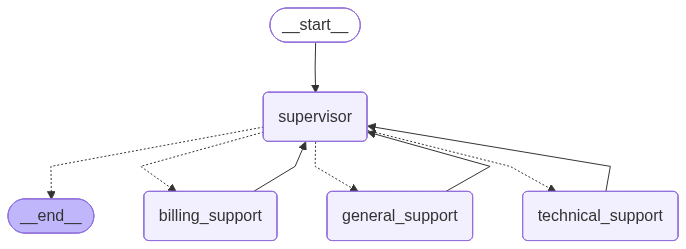

In [131]:
from langchain.tools import BaseTool

new_handoff_tools: list[BaseTool] = [tech_handoff, billing_handoff, general_handoff]

# Supervisor prompt 재작성!
SUPERVISOR_PROMPT = """
You are a customer support routing supervisor.

---
**CRITICAL: You CANNOT answer questions yourself**
---

[YOUR ONLY JOB] 
Read the user's question and delegate to exactly ONE specialist.

[DECISION PROCESS]
1. Carefully read the user's request
2. Check each delegation tool's description
3. Select the ONE tool that best matches
4. Call that tool immediately

[RULES]
- NEVER provide direct answers
- ALWAYS use exactly ONE delegation tool
- If unsure, default to general_support
- Do NOT explain your choice, just delegate

Remember: You are a ROUTER, not an ANSWERER.
""".strip()

# 개선된 Supervisor 생성
supervisor = create_supervisor(
    agents=[technical_support, billing_support, general_support],
    model=ChatOpenAI(model="gpt-4.1-mini", temperature=0),
    tools=new_handoff_tools,
    prompt=SUPERVISOR_PROMPT,
    output_mode="last_message",
    parallel_tool_calls=False,
)

app = supervisor.compile()
app

In [132]:
# 테스트: 올바른 routing을 하는지 확인
test_cases = [
    ("My API keeps returning 503 errors", "delegate_to_tech_support"),
    ("I need to see my invoice from last month", "delegate_to_billing"),
    ("How do I reset my password?", "delegate_to_general"),
]

for user_question, expected_agent in test_cases:
    print(f"\nTest: '{user_question}'")
    print(f"Expected: {expected_agent}")

    result = app.invoke({"messages": [{"role": "user", "content": user_question}]})

    # Supervisor의 첫 응답에서 tool call 확인
    for msg in result["messages"]:
        if isinstance(msg, AIMessage) and msg.tool_calls:
            tool_name = msg.tool_calls[0]["name"]
            print(f"Actual: {tool_name}")

            if expected_agent in tool_name:
                print("O 올바른 Routing!")
            else:
                print("X 잘못된 Routing")
            break


Test: 'My API keeps returning 503 errors'
Expected: delegate_to_tech_support


HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


Actual: delegate_to_tech_support
O 올바른 Routing!

Test: 'I need to see my invoice from last month'
Expected: delegate_to_billing


HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


Actual: delegate_to_billing
O 올바른 Routing!

Test: 'How do I reset my password?'
Expected: delegate_to_general


HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


Actual: delegate_to_general
O 올바른 Routing!


### 해결 방법 2: Post-Model Guardrail

**핵심 아이디어:** Supervisor의 응답을 검사하여 delegation을 했는지 확인하고, 하지 않았다면 자동으로 재시도 또는 fallback

**장점:**
- 방법 1과 결합 가능 (Custom Descriptions + Guardrail)
- 자동 복구: Delegation 실패 시 재시도
- Fallback 전략: 최종적으로 기본 agent로 라우팅

**단점:**
- Retry 오버헤드: 추가 LLM 호출 발생 가능
- 여전히 100% 보장은 아님 (fallback에 의존)
- 복잡도 증가: Middleware 로직 추가

**권장 사용 시나리오:**
- 높은 안정성이 필요한 경우
- 방법 1로 시작 후 추가 안전망으로

In [133]:
from langchain_core.messages import AIMessage

def delegation_guardrail(state: dict) -> dict:
    """
    Post-model middleware: Supervisor가 delegation을 했는지 확인.

    Args:
        state: Current agent state

    Returns:
        Updated state with retry message if delegation failed,
        or original state if delegation successful
    """
    messages = state.get("messages", [])

    if not messages:
        return state

    last_message = messages[-1]

    # AIMessage이면서 tool_calls가 없는 경우 = 직접 응답 시도
    if isinstance(last_message, AIMessage) and not last_message.tool_calls:
        print("[Guardrail] Delegation failure detected!")
        print(f"     Supervisor tried to answer: '{last_message.content[:50]}...'")

        # Retry 메시지 추가
        retry_message = AIMessage(
            content=(
                "ERROR: You MUST delegate to an agent using a delegation tool. "
                "You are FORBIDDEN from answering directly. "
                "Read the tool descriptions carefully and choose ONE delegation tool."
            ),
            name="system_guardrail",
        )

        print("     → Injecting retry message...")

        return {**state, "messages": messages + [retry_message]}

    # Tool calls가 있으면 정상
    if isinstance(last_message, AIMessage) and last_message.tool_calls:
        tool_names = [tc["name"] for tc in last_message.tool_calls]
        print(f"[Guardrail] Delegation successful: {tool_names}")

    return state

In [134]:
def smart_delegation_guardrail(state: dict) -> dict:
    """Encourage delegation with retries and a final warning.

    Features:
    - 최대 2회 재시도
    - 2회 실패 후 대체 명령 메시지 추가
    - 상태에서 재시도 횟수 추적

    Args:
        state: Current agent state (must contain messages)

    Returns:
        Updated state with retry message or fallback notice
    """
    messages = state.get("messages", [])

    if not messages:
        return state

    last_message = messages[-1]

    retry_count = state.get("_delegation_retry_count", 0)

    if isinstance(last_message, AIMessage) and not last_message.tool_calls:
        if retry_count >= 2:
            print("[Guardrail] Maximum delegation retries reached. Forcing fallback.")
            fallback_message = AIMessage(
                content=(
                    "SYSTEM OVERRIDE: Delegating to general_support (fallback). "
                    "지금 메시지는 강제 라우팅 안내일 뿐 실제 Tool 호출은 아닙니다."
                ),
                name="system_fallback",
            )

            return {
                **state,
                "messages": messages + [fallback_message],
                "_delegation_retry_count": 0,
                "_forced_fallback": True,
            }

        warning_message = AIMessage(
            content=(
                f"경고 (재시도 {retry_count + 1}/2): 반드시 delegation tool을 사용하세요. "
                "직접 답변은 허용되지 않습니다. 가능한 선택지: "
                "delegate_to_tech_support, delegate_to_billing, delegate_to_general."
            ),
            name="system_guardrail",
        )

        print(f"[Guardrail] Delegation 실패 감지 (재시도 {retry_count + 1}/2)")
        return {
            **state,
            "messages": messages + [warning_message],
            "_delegation_retry_count": retry_count + 1,
        }

    if isinstance(last_message, AIMessage) and last_message.tool_calls:
        if retry_count > 0:
            print(f"Delegation 성공: {retry_count}회 재시도 후 성공")
        return {**state, "_delegation_retry_count": 0}

    return state

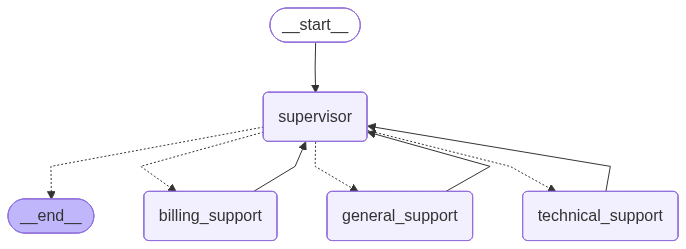

In [135]:
# Guardrail을 적용한 Supervisor 생성
# 방법 1(Custom Descriptions) + 방법 2(Guardrail) 결합

enterprise_supervisor = create_supervisor(
    agents=[technical_support, billing_support, general_support],
    model=ChatOpenAI(model="gpt-5-mini", temperature=0),
    tools=new_handoff_tools,  # 방법 1의 개선된 tools
    prompt=SUPERVISOR_PROMPT,  # 방법 1의 개선된 prompt
    post_model_hook=smart_delegation_guardrail,  # ← Guardrail 추가
    output_mode="last_message",
    parallel_tool_calls=False,
)

enterprise_app = enterprise_supervisor.compile()
enterprise_app

### 해결 방법 3: Forced Delegation with Conditional Edges

**핵심 아이디어:** Tool calling에 의존하지 않고, Conditional Edges로 라우팅을 강제하여 100% delegation 보장

**장점:**
- 100% 보장: LLM이 tool을 안 써도 무조건 delegation
- 결정론적: 확률적 행동 제거
- 빠름: Tool calling 오버헤드 없음
- 투명함: 라우팅 로직이 명시적

**단점:**
- `create_supervisor()` 사용 불가 (수동 구현 필요)
- 복잡도 증가: StateGraph를 직접 구성
- 유연성 감소: Dynamic routing 어려움

**권장 사용 시나리오:**
- Mission-critical 시스템 (금융, 의료, 국방 등 절대로 실패하지 않아야 하는 경우)
- Delegation 실패가 절대 불가능한 경우
- Routing 로직이 단순하고 명확한 경우
- 방법 1, 2로도 불충분할 때

In [136]:
from pydantic import BaseModel, Field
from typing import Literal

class RouterDecision(BaseModel):
    """Supervisor's routing decision."""

    agent_name: Literal["technical_support", "billing_support", "general_support"] = (
        Field(description="The name of the agent to delegate to")
    )
    reasoning: str = Field(
        description="Brief explanation of why this agent was chosen (1-2 sentences)"
    )

In [139]:
from langgraph.types import Command

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Supervisor Function (Forced Routing)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


def supervisor_forced(state: dict) -> Command[Literal["technical_support", "billing_support", "general_support"]]:
    """
    항상 에이전트에게 위임(delegate)하는 Supervisor입니다.

    with_structured_output()을 사용하여 LLM이 RouterDecision을 반환하도록 강제합니다.
    도구 호출은 전혀 사용하지 않으며, 순수한 구조화된 출력만 사용합니다.

    Args:
        state: Current state with messages

    Returns:
        Command object with goto to the selected agent
    """
    messages = state.get("messages", [])

    # Create structured LLM (no tools!)
    structured_llm = ChatOpenAI(
        model="gpt-4.1-mini", temperature=0
    ).with_structured_output(RouterDecision)

    # Routing prompt
    routing_prompt = """You are a customer support routing supervisor.

Analyze the user's question and determine which specialist agent should handle it.

Available agents:
- technical_support: System errors, bugs, API failures, performance issues
- billing_support: Invoices, payments, refunds, pricing, subscription changes
- general_support: Product information, how-to questions, account setup, password resets

IMPORTANT: You MUST select exactly one agent. Default to general_support if unsure.
"""

    # Get routing decision (guaranteed to be RouterDecision)
    decision: RouterDecision = structured_llm.invoke(
        [{"role": "system", "content": routing_prompt}, *messages]
    )

    print(f"\n[Supervisor] Routing to: {decision.agent_name}")
    print(f"[Supervisor] Reason: {decision.reasoning}")

    # Return Command to go to the selected agent
    return Command(
        goto=decision.agent_name,
        update={"messages": messages},  # Pass messages to worker
    )

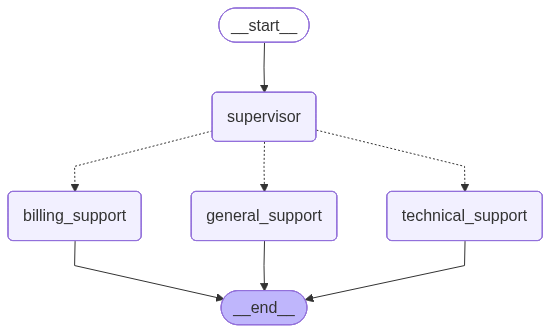

In [140]:
from langgraph.graph import StateGraph, MessagesState, START, END

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# StateGraph 구성
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

forced_graph = StateGraph(MessagesState)

# 노드
forced_graph.add_node("supervisor", supervisor_forced)
forced_graph.add_node("technical_support", technical_support)  # From Section 7
forced_graph.add_node("billing_support", billing_support)
forced_graph.add_node("general_support", general_support)

# 엣지
forced_graph.add_edge(START, "supervisor")

# agents -> END (workers finish)
forced_graph.add_edge("technical_support", END)
forced_graph.add_edge("billing_support", END)
forced_graph.add_edge("general_support", END)

# Command 로직
forced_app = forced_graph.compile()
forced_app 

In [141]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 4. Test Forced Delegation
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
test_questions = [
    "My API is returning 503 errors",
    "I need a copy of my latest invoice",
    "How do I change my password?",
]

for question in test_questions:
    print(f"\n[User] {question}")

    try:
        result = forced_app.invoke(
            {"messages": [{"role": "user", "content": question}]}
        )

        # Find final answer
        for msg in reversed(result["messages"]):
            if isinstance(msg, AIMessage) and msg.content:
                print(f"[Worker] {msg.content[:100]}...")
                break

        print("Delegation 성공!!")

    except Exception as e:
        print(f"Error: {e}")


[User] My API is returning 503 errors


HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"



[Supervisor] Routing to: technical_support
[Supervisor] Reason: The user is experiencing 503 errors with their API, which indicates a system or server issue best handled by technical support.


HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


[Worker] The API service is currently operational with a response time of 120ms. The 503 errors might be caus...
Delegation 성공!!

[User] I need a copy of my latest invoice


...

[Worker] To assist you with retrieving your latest invoice, could you please provide me with your customer ID...
Delegation 성공!!

[User] How do I change my password?


HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"



[Supervisor] Routing to: general_support
[Supervisor] Reason: The user's question is about changing a password, which falls under account setup and password resets handled by general support.


HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


[Worker] To change your password, please go to Settings > Security > Reset Password. If you need further assi...
Delegation 성공!!


# `create_agent()` + Middleware로 Supervisor 패턴 구현하기


**참고 문서:**
- [Agent Middleware](https://docs.langchain.com/oss/python/langchain/agents/middleware)
- [StateGraph Low-Level API](https://langchain-ai.github.io/langgraph/concepts/low_level)

## 8.1 수동 구현의 필요성

`create_supervisor()`는 편리하지만, 다음과 같은 경우 수동 구현이 필요합니다:

1. **커스텀 라우팅 로직** - 복잡한 조건부 라우팅
2. **추가 라이브러리 배제** - `langgraph-supervisor` 의존성 제거
3. **세밀한 제어** - Handoff 메커니즘 완전 커스터마이징
4. **학습 목적** - 내부 동작 원리 이해

## 8.2 구현 전략

Middleware를 활용하여 Supervisor 패턴을 구현합니다:

1. **`@dynamic_prompt`** - Worker에게 전달할 작업 설명 생성
2. **Custom routing logic** - Supervisor가 작업 분류
3. **Sequential execution** - Supervisor → Worker → Supervisor

### 아키텍처

```
User Query
    |
    v
[Router Agent] (Supervisor)
    |
    |---> Determine worker
    |
    v
[Worker Agent]
    |
    v
[Router Agent] (Final response)
```

## 8.3 구현: 간단한 Task Router

수학 문제와 텍스트 작업을 구분하는 간단한 Multi-Agent 시스템을 구현합니다.

In [142]:
# Worker Agent Tools
@tool
def advanced_multiply(a: float, b: float) -> float:
    """Multiply two numbers with logging.

    Args:
        a: First number
        b: Second number

    Returns:
        Product of a and b
    """
    result = a * b
    return result


@tool
def advanced_add(a: float, b: float) -> float:
    """Add two numbers with logging.

    Args:
        a: First number
        b: Second number

    Returns:
        Sum of a and b
    """
    result = a + b
    return result


@tool
def summarize_text(text: str, max_words: int = 50) -> str:
    """Summarize text to specified word count.

    Args:
        text: Text to summarize
        max_words: Maximum words in summary

    Returns:
        Summarized text
    """
    words = text.split()
    if len(words) <= max_words:
        return text
    summary = " ".join(words[:max_words]) + "..."
    return summary

In [143]:
# Task classification using dynamic prompt
@dynamic_prompt
def router_prompt(request):
    """Route tasks to appropriate workers based on content.

    This middleware analyzes the user query and determines
    which specialized worker should handle it.

    Args:
        request: Model request object

    Returns:
        Dynamic system prompt with routing instructions
    """
    messages = request.state["messages"]
    
    # Find the LAST HumanMessage (not just last message)
    last_human_msg = None
    for msg in reversed(messages):
        if isinstance(msg, HumanMessage):
            last_human_msg = msg
            break

    if last_human_msg:
        content = last_human_msg.content.lower()

        # Simple keyword-based routing
        math_keywords = [
            "calculate",
            "multiply",
            "add",
            "math",
            "number",
            "*",
            "+",
            "-",
            "/",
        ]
        text_keywords = ["summarize", "write", "text", "explain", "describe"]

        has_math = any(kw in content for kw in math_keywords)
        has_text = any(kw in content for kw in text_keywords)

        if has_math:
            print(f"[Router] Detected: MATH task (from: '{content[:50]}...')")
            return """You are a mathematics expert with calculation tools.

Use your tools to solve mathematical problems step by step.
Provide clear explanations of your calculations."""

        elif has_text:
            print(f"[Router] Detected: TEXT task (from: '{content[:50]}...')")
            return """You are a text processing expert.

Use your summarization tools to process and analyze text.
Provide concise and informative results."""

    # Default: General assistant
    print("[Router] Detected: GENERAL task (no human message or no keywords)")
    return """You are a helpful general assistant.

Provide clear and accurate information.
Use available tools when appropriate."""


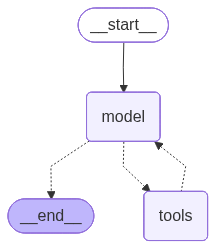

In [144]:
# Router Agent 생성
# 모든 도구를 가지고 있지만, dynamic prompt로 역할 전환
router_agent = create_agent(
    model="openai:gpt-4.1-mini",
    tools=[advanced_multiply, advanced_add, summarize_text],
    name="task_router",
    middleware=[
        router_prompt,  # Dynamic prompt가 작업 타입에 따라 System 의 역할을 변경
    ],
)
router_agent

In [145]:
# Test 1: Math Task
result1 = router_agent.invoke(
    {"messages": [HumanMessage(content="Calculate 15 multiply by 8. Respond in Korean.")]}
)

for msg in result1["messages"]:
    if isinstance(msg, AIMessage) and not msg.tool_calls:
        msg.pretty_print()

[Router] Detected: MATH task (from: 'calculate 15 multiply by 8. respond in korean....')


HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


[Router] Detected: MATH task (from: 'calculate 15 multiply by 8. respond in korean....')


HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


================================== Ai Message ==================================

15 곱하기 8은 120입니다.


In [ ]:
# Test 2: Text Task
long_text = """Artificial intelligence has revolutionized many aspects of modern life. 
From healthcare to transportation, AI systems are helping to solve complex problems. 
Machine learning algorithms can now analyze vast amounts of data and identify patterns 
that would be impossible for humans to detect. However, the development of AI also raises 
important ethical questions about privacy, bias, and the future of work."""

result2 = router_agent.invoke(
    {
        "messages": [
            HumanMessage(
                content=f"Summarize the following text to 20 words: {long_text} Respond in Korean."
            )
        ]
    }
)

for msg in result2["messages"]:
    if isinstance(msg, AIMessage) and not msg.tool_calls:
        msg.pretty_print()

[Router] Detected: TEXT task (from: 'summarize the following text to 20 words: artifici...')


HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


[Router] Detected: TEXT task (from: 'summarize the following text to 20 words: artifici...')


HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"



Agent Response:
================================== Ai Message ==================================

인공지능은 현대 생활의 여러 측면을 혁신했으며, 데이터 분석과 문제 해결을 돕지만, 윤리적 문제도 제기합니다.


In [147]:
# Test 3: General Task
result3 = router_agent.invoke(
    {"messages": [HumanMessage(content="What is the capital of France? Respond in Korean.")]}
)

for msg in result3["messages"]:
    if isinstance(msg, AIMessage) and not msg.tool_calls:
        print(msg.content)

[Router] Detected: GENERAL task (no human message or no keywords)


HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


프랑스의 수도는 파리입니다.


## 8.4 비즈니스에서 사용할 수 있는 Multi-Agent with State

위 예제는 단일 Agent가 역할을 전환하는 방식이었습니다.  
Multi-Agent 시스템을 구현하려면 LangGraph의 `StateGraph(Graph API)`를 사용하셔서 직접 구현하시는걸 추천드리며, 각 Agent는 완전히 격리되어야 합니다.

### 핵심 차이점

**단일 Agent + Dynamic Prompt (위 예제):**
- 장점: 간단한 구현
- 단점: 모든 도구가 항상 노출됨, 진정한 격리 없음

**StateGraph + Multiple Agents (진정한 Multi-Agent):**
- 장점: 완전한 격리, 각 Agent는 자신만의 도구 세트
- 단점: 더 복잡한 구현

이제 실제로 실행 가능한 StateGraph 기반 Multi-Agent 시스템을 구축해봅시다.

In [148]:
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command

# State definition for multi-agent system
class MultiAgentState(TypedDict):
    """State for multi-agent routing system."""

    messages: Annotated[list, add_messages]
    next_agent: str  # Which agent to route to

In [149]:
# Math agent with ONLY math tools
math_agent_isolated = create_agent(
    model="openai:gpt-4.1-mini",
    tools=[advanced_multiply, advanced_add],
    name="math_agent",
    system_prompt="""You are a mathematics expert.Your capabilities:- Multiply numbers using advanced_multiply- Add numbers using advanced_addProvide step-by-step mathematical solutions.""",
)  # Text agent with ONLY text tools

text_agent_isolated = create_agent(
    model="openai:gpt-4.1-mini",
    tools=[summarize_text],
    name="text_agent",
    system_prompt="""You are a text processing expert.Your capabilities:- Summarize text using summarize_text toolProvide clear and concise text processing.""",
)

In [150]:
def route_to_agent(state: MultiAgentState) -> Command[Literal["math_agent", "text_agent", END]]:
    """
    Analyze user query and route to appropriate agent.

    This is a DETERMINISTIC router - no LLM tool calling needed.
    Routes based on keyword analysis.

    Args:
        state: Current multi-agent state

    Returns:
        Command with goto directive
    """
    last_message = state["messages"][-1]
    content = last_message.content.lower()

    # Keyword-based routing (deterministic)
    math_keywords = ["calculate", "multiply", "add", "math", "number", "*", "+"]
    text_keywords = ["summarize", "text", "write", "summary"]

    has_math = any(kw in content for kw in math_keywords)
    has_text = any(kw in content for kw in text_keywords)

    if has_math:
        print("[Router] Detected MATH query → Routing to math_agent")
        return Command(goto="math_agent")
    elif has_text:
        print("[Router] Detected TEXT query → Routing to text_agent")
        return Command(goto="text_agent")
    else:
        print("[Router] No specialized agent needed → END")
        return Command(goto=END)

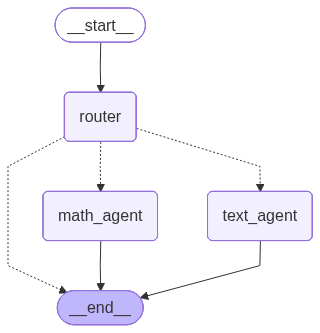

In [78]:
# Create StateGraph
workflow: StateGraph = StateGraph(MultiAgentState)

# Add nodes
workflow.add_node("router", route_to_agent)
workflow.add_node("math_agent", math_agent_isolated)
workflow.add_node("text_agent", text_agent_isolated)

# Add edges
workflow.add_edge(START, "router")
workflow.add_edge("math_agent", END)
workflow.add_edge("text_agent", END)

multi_agent_app = workflow.compile()
multi_agent_app

In [151]:
# Test 1: Math Query
result = multi_agent_app.invoke(
    {
        "messages": [HumanMessage(content="Calculate 15 multiplied by 8 Respond in Korean.")],
        "next_agent": "",
    }
)

for msg in result["messages"]:
    if isinstance(msg, AIMessage) and not msg.tool_calls:
        msg.pretty_print()

[Router] Detected MATH query → Routing to math_agent


HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


================================== Ai Message ==================================

15에 8을 곱한 값은 120입니다.


In [152]:
# Test 2: Text Query
long_text = """
Artificial Intelligence has evolved dramatically over the past decade.
Machine learning models have become increasingly sophisticated, enabling
applications ranging from natural language processing to computer vision.
The development of large language models has particularly transformed
how we interact with AI systems, making them more accessible and useful
for everyday tasks.
"""

result = multi_agent_app.invoke(
    {
        "messages": [HumanMessage(content=f"Summarize this text: {long_text} Respond in Korean.")],
        "next_agent": "",
    }
)

for msg in result["messages"]:
    if isinstance(msg, AIMessage) and not msg.tool_calls:
        msg.pretty_print()

[Router] Detected TEXT query → Routing to text_agent


HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


================================== Ai Message ==================================

인공지능은 지난 10년간 크게 발전했으며, 기계 학습 모델의 고도화로 자연어 처리와 컴퓨터 비전 등 다양한 응용이 가능해졌습니다. 특히 대형 언어 모델의 개발은 AI와의 상호작용을 혁신적으로 변화시켜 일상 업무에 더 유용하고 접근하기 쉽게 만들었습니다.


---

### 핵심 포인트

**단일 Agent + Dynamic Prompt vs StateGraph + Multiple Agents**

| Aspect | Dynamic Prompt | StateGraph |
|--------|---------------|------------|
| 구현 복잡도 | 간단함 | 꽤나 복잡 |
| Tool 격리 | 모든 Agent가 모든 도구 접근 | Agent별 완전 격리 |
| 라우팅 방식 | 확률적 (LLM 판단) | 결정론적 (명시적 로직) |
| 성능 | 빠름 (단일 Agent) | 느림 (여러 Agent 생성) |
| 디버깅 | 어려움 (LLM 행동 추적) | 쉬움 (명시적 흐름) |
| 확장성 | 제한적 | 높음 (Agent 무한 추가) |

**언제 각각 사용할까?**

**Dynamic Prompt 방식:**
- 간단한 라우팅 (2-3개 역할)
- 빠른 프로토타이핑
- 도구 격리가 중요하지 않음
- LLM이 문맥 기반 판단해야 함

**StateGraph 직접 구현 방식:**
- 복잡한 Multi-Agent 시스템 (5+ agents)
- 완전한 도구 격리 필요
- 명시적 제어 흐름 필요
- Production 등의 안정적인 환경이 필요할 경우
- 감사(audit) 및 모니터링 필요

**참고:**
- LangGraph StateGraph 공식 문서: https://langchain-ai.github.io/langgraph/concepts/low_level
- Multi-Agent Systems: https://langchain-ai.github.io/langgraph/concepts/multi_agent

## 8.5 프로덕션 수준의 Supervisor with Middleware

**목표**: `create_agent()` + Middleware만으로 프로덕션 수준의 Supervisor 패턴 구현

`create_supervisor()`는 편리하지만 다음과 같은 한계가 있습니다:
1. LLM이 handoff tool을 호출하지 않을 수 있음 (불안정)
2. Worker 에러가 전체 시스템에 전파
3. Delegation 로직 커스터마이징 제한
4. 외부 라이브러리 의존성

이번 섹션에서는 **Middleware를 활용**하여 이러한 문제들을 해결하고, 더 나은 제어와 안정성을 제공하는 Supervisor를 구현합니다.

#### 8.5.1 아키텍처 설계

```
Supervisor Agent (create_agent)
├── Tools: [handoff_to_tech, handoff_to_billing, handoff_to_general]
├── Middleware Stack:
│   ├── logging_middleware (before_model)
│   ├── context_isolation_middleware (before_model)
│   ├── retry_middleware (wrap_tool_call)
│   ├── delegation_middleware (wrap_tool_call) <- 핵심!
│   └── validation_middleware (after_model)
│
└── Delegates to Worker Agents:
    ├── Tech Agent (create_agent)
    ├── Billing Agent (create_agent)
    └── General Agent (create_agent)
```

**핵심 아이디어:**
- **Supervisor는 하나의 `create_agent()`**: Middleware 완벽 활용
- **Delegation Middleware**: `handoff_to_*` tool 호출을 intercept하여 실제 worker 실행
- **Worker도 `create_agent()`**: 독립적인 tool, middleware, 설정

#### 8.5.2 Handoff Tools 정의

Handoff tool은 Supervisor가 worker에게 작업을 위임하기 위한 인터페이스입니다.

In [153]:
from langchain.tools import tool

@tool
def handoff_to_tech(task: str) -> str:
    """
    기술 지원이 필요한 경우 Technical Support Agent에게 위임합니다.

    다음과 같은 경우 사용:
    - 계정 로그인 문제
    - 오류 메시지 해결
    - 시스템 장애 문제

    Args:
        task: 기술 지원이 필요한 작업 설명
    """
    # 실제 로직은 middleware에서 처리됨
    return f"Delegating to tech support: {task}"


@tool
def handoff_to_billing(task: str) -> str:
    """
    결제/청구 관련 문제는 Billing Agent에게 위임합니다.

    다음과 같은 경우 사용:
    - 결제 오류
    - 환불 요청
    - 구독 변경

    Args:
        task: 결제 관련 작업 설명
    """
    return f"Delegating to billing: {task}"


@tool
def handoff_to_general(task: str) -> str:
    """
    일반적인 문의는 General Information Agent에게 위임합니다.

    다음과 같은 경우 사용:
    - 회사 정보 문의
    - 서비스 설명
    - 기타 일반 문의

    Args:
        task: 일반 문의 내용
    """
    return f"Delegating to general info: {task}"

#### 8.5.3 Worker Agents 생성

각 Worker agent는 독립적인 tool set과 전문 지식을 가집니다.

In [154]:
# Worker 전용 tools
@tool
def query_user_database(user_id: str) -> str:
    """사용자 계정 정보를 데이터베이스에서 조회"""
    # 실제로는 DB 조회
    return (
        f"[DB] User {user_id}: account_status=active, email=user{user_id}@example.com"
    )


@tool
def reset_password(user_id: str) -> str:
    """사용자 비밀번호 재설정"""
    return f"[SYSTEM] Password reset email sent to user {user_id}"


@tool
def process_refund(order_id: str) -> str:
    """환불 처리"""
    return f"[PAYMENT] Refund initiated for order {order_id}. Amount: $99.99"


@tool
def check_subscription(user_id: str) -> str:
    """구독 상태 확인"""
    return f"[SUBSCRIPTION] User {user_id} subscription: Premium (expires 2025-12-31)"


@tool
def get_company_info(topic: str) -> str:
    """회사 정보 조회"""
    info_db = {
        "서비스": "AI 기반 고객 지원 플랫폼",
        "회사": "TechCorp Inc. (설립 2020년)",
        "연락처": "support@techcorp.com",
    }
    return info_db.get(topic, f"'{topic}'에 대한 정보를 찾을 수 없습니다.")

In [155]:
# Worker agents with enhanced structured prompts
from langchain.agents import create_agent
from langchain_openai import ChatOpenAI

worker_model = ChatOpenAI(model="gpt-4.1-mini")

# Technical Support Agent
tech_agent: CompiledStateGraph = create_agent(
    model=worker_model,
    tools=[query_user_database, reset_password],
    system_prompt="""[Role]
You are a Technical Support Specialist with expertise in troubleshooting software, hardware, and account access issues.

[Responsibilities]
- Diagnose and resolve technical problems efficiently
- Query user database to retrieve account information
- Reset passwords when authorized and necessary
- Provide clear step-by-step technical guidance
- Escalate complex issues when needed

[Available Tools]
1. `query_user_database`: Retrieve user account information, status, and history
2. `reset_password`: Generate and send new temporary passwords

[Workflow]
1. **Identify**: Gather information about the technical issue
2. **Verify**: Check user account status using database query
3. **Diagnose**: Analyze the problem based on symptoms and data
4. **Resolve**: Apply appropriate solution (e.g., password reset, configuration change)
5. **Confirm**: Verify the issue is resolved with the user

[Guidelines]
- Always verify user identity before performing sensitive operations
- Use tools systematically: query database BEFORE resetting passwords
- Provide clear explanations of technical concepts in simple terms
- Document all actions taken for audit trail
- Maintain professional and empathetic tone throughout

[Response Format]
- Be concise but thorough
- Use bullet points for multi-step instructions
- Confirm successful resolution before closing
""",
    name="tech_support",
)

# Billing Support Agent
billing_agent = create_agent(
    model=worker_model,
    tools=[process_refund, check_subscription],
    system_prompt="""[Role]
You are a Billing and Payment Specialist responsible for handling financial transactions, subscription management, and payment-related inquiries.

[Responsibilities]
- Process refund requests according to company policy
- Manage subscription plans (upgrades, downgrades, cancellations)
- Resolve billing discrepancies and payment issues
- Explain charges and payment methods clearly
- Ensure compliance with financial regulations

[Available Tools]
1. `process_refund`: Issue refunds for eligible transactions
2. `check_subscription`: Retrieve subscription details, billing history, and plan information

[Workflow]
1. **Understand**: Clarify the billing issue or request
2. **Verify**: Check subscription status and payment history
3. **Assess**: Determine eligibility for refunds or plan changes
4. **Execute**: Process approved transactions using appropriate tools
5. **Confirm**: Send confirmation and explain next billing cycle

[Guidelines]
- ALWAYS check subscription details before processing refunds
- Verify refund eligibility based on:
  - Purchase date (within refund window)
  - Subscription status (active/cancelled)
  - Previous refund history
- Explain charges clearly with itemized breakdown when needed
- Be cautious with financial operations - double-check before executing
- Maintain transparency about processing times and policies

[Response Format]
- Provide exact amounts and dates
- Use clear language for financial terms
- Include transaction IDs and confirmation numbers
- Set accurate expectations for refund processing time
""",
    name="billing_support",
)

# General Information Agent
general_agent = create_agent(
    model=worker_model,
    tools=[get_company_info],
    system_prompt="""[Role]
You are a Customer Service Representative specializing in general inquiries, product information, and company policies.

[Responsibilities]
- Answer questions about company services and products
- Provide information on policies, procedures, and features
- Guide users to appropriate resources and documentation
- Route complex issues to specialized agents when necessary
- Deliver excellent customer experience

[Available Tools]
1. `get_company_info`: Retrieve official company information, policies, service details, and FAQs

[Workflow]
1. **Listen**: Understand the customer's question or concern
2. **Research**: Query company information database for accurate details
3. **Explain**: Provide clear, comprehensive answers
4. **Guide**: Offer next steps or additional resources
5. **Follow-up**: Ask if the customer needs further assistance

[Guidelines]
- Use the company info tool to ensure accuracy - never guess
- Provide up-to-date information from official sources
- Break down complex policies into easy-to-understand points
- Offer proactive suggestions for related questions
- Identify when to route to specialized agents:
  - Technical issues → Technical Support
  - Billing/refunds → Billing Support

[Response Format]
- Structure answers with clear headings when covering multiple topics
- Use bullet points for policies and features
- Include relevant links or documentation references
- Keep language simple and jargon-free
- End with "Is there anything else I can help you with?"

[Tone]
- Friendly and approachable
- Professional and knowledgeable
- Patient and understanding
- Positive and helpful
""",
    name="general_info",
)

# Worker registry
WORKER_REGISTRY = {
    "tech": tech_agent,
    "billing": billing_agent,
    "general": general_agent,
}

#### 8.5.4 Middleware 구현

Middleware는 agent 실행의 각 단계를 제어합니다.

#### (1) Delegation Middleware - 핵심!

`handoff_to_*` tool 호출을 감지하고 실제 worker agent를 실행합니다.

In [157]:
from langchain.agents.middleware import wrap_tool_call
from langchain_core.messages import ToolMessage, HumanMessage
import logging
import time

# Logging setup
logging.basicConfig(level=logging.INFO, format="%(message)s")
logger = logging.getLogger(__name__)


@wrap_tool_call
def delegation_with_retry_middleware(request, handler):
    """
    핸드오프(handoff) 도구를 감지하고 워커에게 위임하며 재시도 로직을 포함합니다.
    
    이 미들웨어는:
        - 호출된 도구가 핸드오프 도구인지 (handoff_to_*) 확인합니다.
        - 핸드오프 도구이면: 적절한 워커 에이전트로 위임하고 재시도합니다.
        - 핸드오프 도구가 아니면: 일반 도구 실행을 재시도 로직과 함께 수행합니다.
    
    Args:
        request: ToolCallRequest containing tool_call info (name, args, id)
        handler: Callable to execute the tool call
        
    Returns:
        ToolMessage with worker's response or error message
    """
    tool_call = request.tool_call
    tool_name = tool_call.get("name", "")
    tool_args = tool_call.get("args", {})
    tool_call_id = tool_call.get("id", "")
    
    max_retries = 3

    # --- HANDOFF DELEGATION LOGIC ---
    if tool_name.startswith("handoff_to_"):
        worker_name = tool_name.replace("handoff_to_", "")
        logger.info(f"[DELEGATION] Starting delegation to worker: {worker_name}")
        
        task = tool_args.get("task", "")
        logger.info(f"[DELEGATION] Task: {task[:100]}...")

        # Get worker agent from registry
        worker_agent = WORKER_REGISTRY.get(worker_name)

        if not worker_agent:
            error_msg = f"ERROR: Unknown worker '{worker_name}'"
            logger.error(f"[DELEGATION] {error_msg}")
            return ToolMessage(
                content=error_msg,
                tool_call_id=tool_call_id,
                status="error"
            )

        # Execute worker with retry
        for attempt in range(max_retries):
            try:
                response = worker_agent.invoke({"messages": [HumanMessage(content=task)]})

                # Extract worker's final response
                if isinstance(response, dict) and "messages" in response:
                    last_message = response["messages"][-1]
                    result = last_message.content
                else:
                    result = str(response)

                if attempt > 0:
                    logger.info(f"[DELEGATION] Worker '{worker_name}' succeeded on attempt {attempt + 1}")
                else:
                    logger.info(f"[DELEGATION] Worker '{worker_name}' completed successfully")
                
                return ToolMessage(
                    content=result,
                    tool_call_id=tool_call_id
                )

            except Exception as e:
                logger.warning(f"[DELEGATION] Worker '{worker_name}' failed on attempt {attempt + 1}/{max_retries}: {type(e).__name__}: {str(e)[:100]}")

                if attempt < max_retries - 1:
                    wait_time = 2 ** attempt
                    logger.info(f"[DELEGATION] Waiting {wait_time}s before retry...")
                    time.sleep(wait_time)
                else:
                    logger.error(f"[DELEGATION] Worker '{worker_name}' failed after {max_retries} attempts")
                    
                    fallback_response = f"""I apologize, but an error occurred while processing your request.

Worker: {worker_name}
Error: {type(e).__name__}: {str(e)}

Please try again later or contact support if the issue persists."""
                    
                    return ToolMessage(
                        content=fallback_response,
                        tool_call_id=tool_call_id,
                        status="error"
                    )

    # --- REGULAR TOOL RETRY LOGIC ---
    for attempt in range(max_retries):
        try:
            result = handler(request)
            
            if attempt > 0:
                logger.info(f"[RETRY] Tool '{tool_name}' succeeded on attempt {attempt + 1}/{max_retries}")
            
            return result
            
        except Exception as e:
            logger.warning(f"[RETRY] Tool '{tool_name}' failed on attempt {attempt + 1}/{max_retries}: {type(e).__name__}: {str(e)[:100]}")

            if attempt < max_retries - 1:
                wait_time = 2 ** attempt
                logger.info(f"[RETRY] Waiting {wait_time}s before next retry...")
                time.sleep(wait_time)
            else:
                logger.error(f"[RETRY] Tool '{tool_name}' failed after {max_retries} attempts")
                
                error_content = f"""Tool execution failed after {max_retries} retry attempts.

Tool: {tool_name}
Error: {type(e).__name__}: {str(e)}

This tool is temporarily unavailable. Please try again later or contact support."""
                
                return ToolMessage(
                    content=error_content,
                    tool_call_id=tool_call_id,
                    status="error"
                )

#### 8.5.5 Supervisor Agent 생성

모든 middleware를 통합하여 최종 Supervisor를 생성합니다.

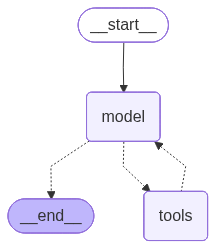

In [158]:
# Supervisor
from langchain.agents import create_agent

supervisor_with_middleware = create_agent(
    model=ChatOpenAI(model="gpt-4.1", temperature=0),
    tools=[handoff_to_tech, handoff_to_billing, handoff_to_general],
    system_prompt="""
[Role]
You are a Supervisor Agent responsible for intelligently routing customer inquiries to the appropriate specialized support agent.

[Responsibilities]
- Analyze incoming customer inquiries to determine the nature of the issue
- Route requests to the most qualified specialist agent
- Ensure efficient handoff without attempting to resolve issues directly
- Handle ambiguous cases by selecting the best-fit agent based on available context

[Available Tools]
1. `handoff_to_tech`: Transfer to Technical Support for system, login, and technical issues
2. `handoff_to_billing`: Transfer to Billing Support for payments, refunds, and subscriptions
3. `handoff_to_general`: Transfer to General Information for company info and general inquiries

[Routing Rules]

**Technical Support** (`handoff_to_tech`)
- Login issues, password problems, account access
- System errors, bugs, technical malfunctions
- Software/hardware troubleshooting
- API or integration issues
- Performance and connectivity problems

**Billing Support** (`handoff_to_billing`)
- Refund requests and payment disputes
- Subscription management (upgrade, downgrade, cancellation)
- Billing inquiries and invoice questions
- Payment method issues
- Pricing and plan information

**General Information** (`handoff_to_general`)
- Company policies and procedures
- Product features and capabilities
- Service availability and hours
- General questions about the company
- Documentation and resource requests

[Workflow]
1. **Analyze**: Read the customer inquiry carefully to identify key indicators
2. **Classify**: Determine the primary category (technical, billing, or general)
3. **Route**: Call the appropriate handoff tool immediately
4. **No Direct Response**: Never attempt to answer the query yourself

[Guidelines]
- ALWAYS use exactly ONE handoff tool - routing is mandatory
- NEVER provide direct answers or solutions
- When multiple categories apply, prioritize:
  1. Technical issues (if system functionality is impaired)
  2. Billing issues (if money/refunds are involved)
  3. General information (for everything else)
- For ambiguous cases, use contextual clues:
  - Mentions of errors/bugs → Technical
  - Mentions of charges/payments → Billing  
  - Questions starting with "What/How/When" → General
- Route immediately upon classification - do not wait for more information

[Response Pattern]
You should NOT generate a text response. Your output should be a tool call only.

[CRITICAL RULES (READ CAREFULLY)]
1) YOUR ONLY JOB: delegate to exactly ONE of the delegation tools: 
   - delegate_to_tech_support
   - delegate_to_billing
   - delegate_to_general
2) YOU MUST NOT generate any natural-language answer, explanation, or commentary.
3) YOU MUST OUTPUT EXACTLY ONE JSON OBJECT (no surrounding text, no backticks, no explanation).
   The JSON schema MUST be:
   {
     "name": "<tool_name>",              // one of the three tool names above
     "args": {"task": "<short task text>"}  // plain string describing the task to the worker
   }
4) If uncertain, choose "delegate_to_general". Do not create new tool names.
5) Keep the "task" concise but include essential context (issue, identifiers).


[Examples]

Query: "I can't log into my account"
→ Action: `handoff_to_tech`

Query: "I want a refund for last month"
→ Action: `handoff_to_billing`

Query: "What are your business hours?"
→ Action: `handoff_to_general`

Query: "My payment failed and I'm locked out"
→ Action: `handoff_to_tech` (technical issue takes priority)""",
    middleware=[
        # TODO: 추가적인 미들웨어 적용 가능
        # Wrap Tool Call
        delegation_with_retry_middleware,  # Worker 실행 + 재시도
    ],
    name="supervisor_agent",
)
supervisor_with_middleware

#### 8.5.6 실행 예제

다양한 시나리오로 Supervisor의 delegation 동작을 테스트합니다.

In [159]:
# 기술 지원 요청 테스트
response1 = supervisor_with_middleware.invoke(
    {
        "messages": [
            HumanMessage(
                content="로그인이 안 돼요. 비밀번호를 재설정하고 싶어요. 제 사용자 ID는 user123입니다."
            )
        ]
    }
)

response1["messages"][-1].pretty_print()

HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
[DELEGATION] Starting delegation to worker: tech
[DELEGATION] Task: 로그인 불가 및 비밀번호 재설정 요청 (사용자 ID: user123)...
HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
[DELEGATION] Worker 'tech' completed successfully
HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


================================== Ai Message ==================================

{
  "name": "handoff_to_tech",
  "args": {"task": "로그인 불가 및 비밀번호 재설정 요청 (사용자 ID: user123)"}
}


In [160]:
# 환불 요청 (Billing Support) 테스트
response2 = supervisor_with_middleware.invoke(
    {
        "messages": [
            HumanMessage(
                content="지난주에 결제한 주문을 환불하고 싶습니다. 주문번호는 ORD12345입니다."
            )
        ]
    }
)

response2["messages"][-1].pretty_print()

HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
[DELEGATION] Starting delegation to worker: billing
[DELEGATION] Task: 환불 요청, 주문번호 ORD12345...
HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
[DELEGATION] Worker 'billing' completed successfully
HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


================================== Ai Message ==================================

{
  "name": "handoff_to_billing",
  "args": {"task": "환불 요청, 주문번호 ORD12345"}
}


In [161]:
# 회사 정보 (General Info) 등 일반 문의
response3 = supervisor_with_middleware.invoke(
    {"messages": [HumanMessage(content="귀사의 서비스에 대해 더 알고 싶습니다.")]}
)

response3["messages"][-1].pretty_print()

HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
[DELEGATION] Starting delegation to worker: general
[DELEGATION] Task: 회사 서비스 정보 문의...
HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
[DELEGATION] Worker 'general' completed successfully
HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


================================== Ai Message ==================================

{
  "name": "handoff_to_general",
  "args": {"task": "회사 서비스 정보 문의"}
}
